# March Madness Predictor — ML Bracket Forecasting

**Authors:** Frank McLaughlin, Jonah Simonson  
**Goal:** Predict every NCAA Tournament game using historical data (2008–2025), achieving a Brier score below 0.20

## Approach
- Build a historical game-level dataset from 17 years of tournament matchups
- Engineer matchup-level difference features from KenPom and Barttorvik efficiency stats
- Validate using **leave-one-year-out cross-validation** (the correct method for time series sports data)
- Compare Random Forest, Gradient Boosting, and XGBoost — RF wins decisively
- Apply the trained model to predict the **2026 NCAA Tournament** bracket

---
## 1. Setup & Data Loading

In [4]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import pickle

# Download the Kaggle dataset (nishaanamin/march-madness-data)
path = kagglehub.dataset_download("nishaanamin/march-madness-data")
print("Dataset path:", path)

Dataset path: /Users/frankmclaughlin/.cache/kagglehub/datasets/nishaanamin/march-madness-data/versions/145


---
## 2. Build Historical Game-Level Dataset

The source data has **one row per team per game**. We pair consecutive rows (by `BY YEAR NO`) to form matchups, then merge in efficiency stats from Barttorvik and KenPom.

**Target variable:** Did Team A win? (1 = yes, 0 = no)

In [6]:
# ── Load raw files ─────────────────────────────────────────────────────────────
df_matchups = pd.read_csv(path + '/Tournament Matchups.csv')
df_bart     = pd.read_csv(path + '/KenPom Barttorvik.csv')
df_538      = pd.read_csv(path + '/538 Ratings.csv')

# ── Pair teams into matchups using consecutive BY YEAR NO ──────────────────────
df_matchups = df_matchups.sort_values(['YEAR', 'BY YEAR NO']).reset_index(drop=True)
team_a = df_matchups.iloc[0::2].reset_index(drop=True)
team_b = df_matchups.iloc[1::2].reset_index(drop=True)

games = pd.DataFrame({
    'YEAR'          : team_a['YEAR'],
    'GAME_ID'       : team_a['BY YEAR NO'],
    'CURRENT_ROUND' : team_a['CURRENT ROUND'],
    'TEAM_A'        : team_a['TEAM'],
    'TEAM_A_NO'     : team_a['TEAM NO'],
    'SEED_A'        : team_a['SEED'],
    'SCORE_A'       : team_a['SCORE'],
    'TEAM_B'        : team_b['TEAM'],
    'TEAM_B_NO'     : team_b['TEAM NO'],
    'SEED_B'        : team_b['SEED'],
    'SCORE_B'       : team_b['SCORE'],
})
games['TARGET'] = (games['SCORE_A'] > games['SCORE_B']).astype(int)
print(f"Games built: {len(games)}")
print(games[['YEAR','TEAM_A','SEED_A','TEAM_B','SEED_B','SCORE_A','SCORE_B','TARGET']].head(5).to_string())

Games built: 1070
   YEAR   TEAM_A  SEED_A          TEAM_B  SEED_B  SCORE_A  SCORE_B  TARGET
0  2008  Memphis       1          Kansas       1       68       75       0
1  2008     UCLA       1         Memphis       1       63       78       0
2  2008   Kansas       1  North Carolina       1       84       66       1
3  2008   Xavier       3            UCLA       1       57       76       0
4  2008    Texas       2         Memphis       1       67       85       0


In [9]:
# ── Select Barttorvik features ────────────────────────────────────────────────
bart_cols = [
    'YEAR', 'TEAM NO',
    'KADJ EM', 'KADJ O', 'KADJ D',
    'BADJ EM', 'BADJ O', 'BADJ D',
    'BARTHAG', 'EFG%', 'EFG%D',
    'TOV%', 'TOV%D', 'OREB%', 'DREB%',
    'FTR', 'FTRD', 'ELITE SOS', 'WAB',
    'EXP', 'TALENT', 'WIN%',
]
df_bart_slim = df_bart[bart_cols].copy()

# ── Merge onto Team A and Team B ──────────────────────────────────────────────
games = games.merge(
    df_bart_slim.add_suffix('_A').rename(columns={'YEAR_A':'YEAR', 'TEAM NO_A':'TEAM_A_NO'}),
    on=['YEAR', 'TEAM_A_NO'], how='left'
)
games = games.merge(
    df_bart_slim.add_suffix('_B').rename(columns={'YEAR_B':'YEAR', 'TEAM NO_B':'TEAM_A_NO'}),
    left_on=['YEAR', 'TEAM_B_NO'], right_on=['YEAR', 'TEAM_A_NO'], how='left',
    suffixes=('', '_drop')
)
games = games.drop(columns=[c for c in games.columns if c.endswith('_drop') or c == 'TEAM_A_NO_y'], errors='ignore')

# ── Merge 538 power rating (only available for some years) ───────────────────
df_538_slim = df_538[['YEAR', 'TEAM NO', 'POWER RATING']].copy()
games = games.merge(
    df_538_slim.rename(columns={'TEAM NO':'TEAM_A_NO', 'POWER RATING':'POWER_RATING_A'}),
    on=['YEAR', 'TEAM_A_NO'], how='left'
)
games = games.merge(
    df_538_slim.rename(columns={'TEAM NO':'TEAM_B_NO', 'POWER RATING':'POWER_RATING_B'}),
    on=['YEAR', 'TEAM_B_NO'], how='left'
)

# ── Engineer difference features ─────────────────────────────────────────────
# Models predict better using DIFFERENCES between teams rather than raw stats
stat_bases = [
    'KADJ EM', 'KADJ O', 'KADJ D',
    'BADJ EM', 'BADJ O', 'BADJ D',
    'BARTHAG', 'EFG%', 'EFG%D',
    'TOV%', 'TOV%D', 'OREB%', 'DREB%',
    'ELITE SOS', 'WAB', 'WIN%', 'TALENT', 'EXP',
]
for stat in stat_bases:
    a, b = f'{stat}_A', f'{stat}_B'
    if a in games.columns and b in games.columns:
        games[f'{stat}_DIFF'] = games[a] - games[b]

games['SEED_DIFF']         = games['SEED_A'] - games['SEED_B']
games['POWER_RATING_DIFF'] = games['POWER_RATING_A'] - games['POWER_RATING_B']

# ── Drop 538 (too many nulls) and finalize ───────────────────────────────────
games_clean = games.drop(columns=['POWER_RATING_A', 'POWER_RATING_B', 'POWER_RATING_DIFF'])

print(f"Final shape: {games_clean.shape}")
print(f"Years covered: {sorted(games_clean['YEAR'].unique())}")
print(f"Target distribution:\n{games_clean['TARGET'].value_counts()}")

Final shape: (1070, 71)
Years covered: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Target distribution:
TARGET
0    668
1    402
Name: count, dtype: int64


---
## 3. Random Forest — Feature Importance

We first train a Random Forest using **leave-one-year-out cross-validation** to:
1. Get a reliable Brier score estimate
2. Identify which features are most predictive

**Why leave-one-year-out?** It respects the temporal structure of the data — we never train on the year we're predicting, which prevents data leakage.

2008  Brier: 0.1557  Accuracy: 0.730
2009  Brier: 0.1573  Accuracy: 0.794
2010  Brier: 0.1920  Accuracy: 0.667
2011  Brier: 0.2394  Accuracy: 0.603
2012  Brier: 0.1643  Accuracy: 0.714
2013  Brier: 0.2129  Accuracy: 0.651
2014  Brier: 0.2234  Accuracy: 0.619
2015  Brier: 0.1746  Accuracy: 0.762
2016  Brier: 0.1892  Accuracy: 0.730
2017  Brier: 0.1713  Accuracy: 0.730
2018  Brier: 0.2214  Accuracy: 0.651
2019  Brier: 0.1872  Accuracy: 0.667
2021  Brier: 0.2171  Accuracy: 0.677
2022  Brier: 0.2031  Accuracy: 0.698
2023  Brier: 0.2200  Accuracy: 0.619
2024  Brier: 0.1890  Accuracy: 0.698
2025  Brier: 0.1492  Accuracy: 0.794

Mean Brier: 0.1922  (target < 0.20)
Mean Accuracy: 0.694

Top 15 features:
BADJ EM_DIFF    0.075770
WAB_DIFF        0.073409
KADJ EM_DIFF    0.070051
BARTHAG_DIFF    0.062736
TALENT_DIFF     0.053134
KADJ O_DIFF     0.049650
KADJ D_DIFF     0.048671
EXP_DIFF        0.048616
BADJ O_DIFF     0.045927
BADJ D_DIFF     0.045650
TOV%D_DIFF      0.043279
EFG%D_DIFF      0.04

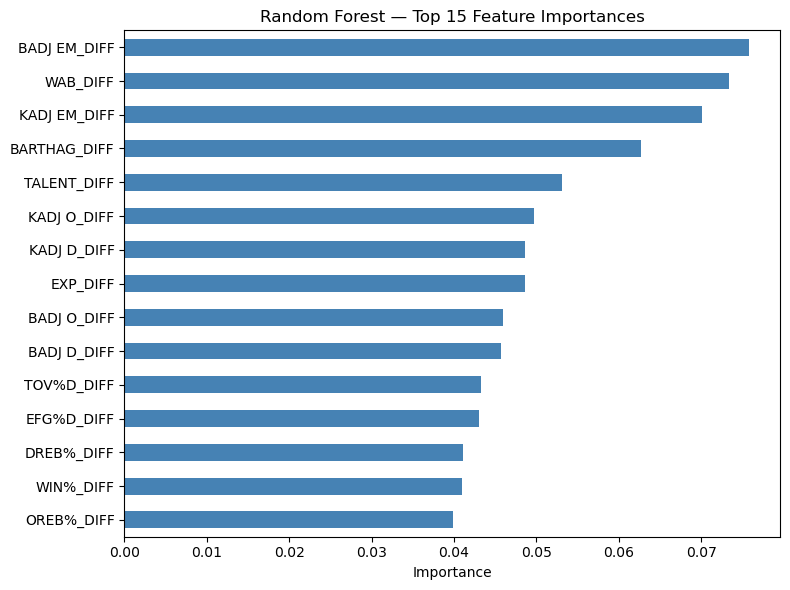

In [12]:
# All diff features + seeds
diff_features = [c for c in games_clean.columns if c.endswith('_DIFF')]
seed_features = ['SEED_A', 'SEED_B', 'SEED_DIFF']
feature_cols  = diff_features + seed_features

X = games_clean[feature_cols]
y = games_clean['TARGET']
years = sorted(games_clean['YEAR'].unique())

# Leave-one-year-out cross validation
brier_scores, accuracies = [], []
for test_year in years:
    train_mask = games_clean['YEAR'] != test_year
    test_mask  = games_clean['YEAR'] == test_year
    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X[train_mask], y[train_mask])
    probs = rf.predict_proba(X[test_mask])[:, 1]
    preds = rf.predict(X[test_mask])
    brier_scores.append(brier_score_loss(y[test_mask], probs))
    accuracies.append((preds == y[test_mask]).mean())
    print(f"{test_year}  Brier: {brier_scores[-1]:.4f}  Accuracy: {accuracies[-1]:.3f}")

print(f"\nMean Brier: {np.mean(brier_scores):.4f}  (target < 0.20)")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")

# Feature importance (trained on 2008–2024, tested on 2025)
train_mask = games_clean['YEAR'] != 2025
rf_full = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_full.fit(X[train_mask], y[train_mask])
importances = pd.Series(rf_full.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("\nTop 15 features:")
print(importances.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 4. Model Comparison — Random Forest vs Gradient Boosting vs XGBoost

We trim to the **top 15 features** identified by RF and compare three models.

**Result:** Random Forest wins decisively. GBM and XGBoost are overconfident in upset-heavy years (2011, 2014, 2023), which gets severely penalized by Brier score.

In [14]:
top_features = [
    'BADJ EM_DIFF', 'KADJ EM_DIFF', 'BARTHAG_DIFF', 'WAB_DIFF',
    'TALENT_DIFF', 'KADJ O_DIFF', 'KADJ D_DIFF', 'EXP_DIFF',
    'BADJ O_DIFF', 'BADJ D_DIFF', 'TOV%D_DIFF', 'EFG%D_DIFF',
    'DREB%_DIFF', 'WIN%_DIFF', 'SEED_DIFF'
]
X_top = games_clean[top_features]
y     = games_clean['TARGET']

gbm_brier, rf_brier, gbm_acc = [], [], []
for test_year in years:
    train_mask = games_clean['YEAR'] != test_year
    test_mask  = games_clean['YEAR'] == test_year
    X_train, X_test = X_top[train_mask], X_top[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    gbm = GradientBoostingClassifier(n_estimators=500, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    gbm_probs = gbm.predict_proba(X_test)[:, 1]
    gbm_brier.append(brier_score_loss(y_test, gbm_probs))
    gbm_acc.append((gbm.predict(X_test) == y_test).mean())

    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_brier.append(brier_score_loss(y_test, rf.predict_proba(X_test)[:, 1]))

    print(f"{test_year}  GBM: {gbm_brier[-1]:.4f}  RF: {rf_brier[-1]:.4f}  GBM Acc: {gbm_acc[-1]:.3f}")

print(f"\nMean GBM Brier: {np.mean(gbm_brier):.4f}")
print(f"Mean RF Brier:  {np.mean(rf_brier):.4f}")
print("\n→ Random Forest is the winner. GBM is overconfident in upset years.")

2008  GBM: 0.1723  RF: 0.1527  GBM Acc: 0.730
2009  GBM: 0.1580  RF: 0.1593  GBM Acc: 0.762
2010  GBM: 0.2283  RF: 0.1941  GBM Acc: 0.667
2011  GBM: 0.2971  RF: 0.2479  GBM Acc: 0.619
2012  GBM: 0.1708  RF: 0.1642  GBM Acc: 0.778
2013  GBM: 0.2495  RF: 0.2112  GBM Acc: 0.619
2014  GBM: 0.3117  RF: 0.2298  GBM Acc: 0.571
2015  GBM: 0.1905  RF: 0.1665  GBM Acc: 0.746
2016  GBM: 0.1828  RF: 0.1802  GBM Acc: 0.762
2017  GBM: 0.1833  RF: 0.1743  GBM Acc: 0.746
2018  GBM: 0.2491  RF: 0.2254  GBM Acc: 0.651
2019  GBM: 0.2122  RF: 0.1838  GBM Acc: 0.667
2021  GBM: 0.2365  RF: 0.2109  GBM Acc: 0.694
2022  GBM: 0.2295  RF: 0.2074  GBM Acc: 0.683
2023  GBM: 0.2780  RF: 0.2132  GBM Acc: 0.619
2024  GBM: 0.2091  RF: 0.1874  GBM Acc: 0.698
2025  GBM: 0.1788  RF: 0.1502  GBM Acc: 0.746

Mean GBM Brier: 0.2199
Mean RF Brier:  0.1917

→ Random Forest is the winner. GBM is overconfident in upset years.


---
## 5. Final Model — 2025 Holdout Evaluation

We train the final RF on **2008–2024** and evaluate on the **2025 tournament** as a true holdout.

We also check probability calibration — a well-calibrated model means that when it says "70% chance", the team wins about 70% of the time.

  2025 HOLDOUT RESULTS
  Brier Score: 0.1502  (target < 0.20) ✓
  Accuracy:    77.8%

  Round of 64          26/32  ████████████████ 81%
  Round of 32          12/16  ███████████████ 75%
  Sweet 16             7/8  █████████████████ 88%
  Elite 8              4/4  ████████████████████ 100%
  Final Four           0/2   0%
  Championship         0/1   0%


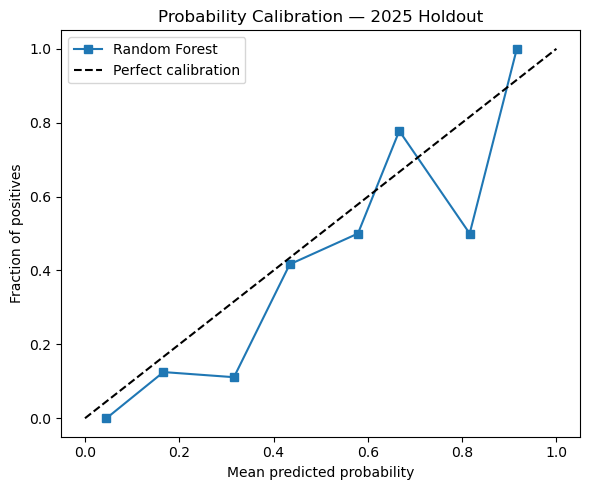

In [16]:
train_mask = games_clean['YEAR'] != 2025
test_mask  = games_clean['YEAR'] == 2025

rf_final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_final.fit(X_top[train_mask], y[train_mask])

probs_2025 = rf_final.predict_proba(X_top[test_mask])[:, 1]
preds_2025 = rf_final.predict(X_top[test_mask])

games_2025 = games_clean[games_clean['YEAR'] == 2025].copy()
results_2025 = games_2025[['CURRENT_ROUND','TEAM_A','SEED_A','TEAM_B','SEED_B','TARGET']].copy()
results_2025['PRED_PROB_A']   = probs_2025.round(3)
results_2025['PREDICTED_WIN'] = preds_2025
results_2025['CORRECT']       = (preds_2025 == results_2025['TARGET']).astype(int)
results_2025['ROUND_NAME']    = results_2025['CURRENT_ROUND'].map({
    64: 'Round of 64', 32: 'Round of 32',
    16: 'Sweet 16', 8: 'Elite 8', 4: 'Final Four', 2: 'Championship'
})

brier_2025 = brier_score_loss(results_2025['TARGET'], probs_2025)

print("=" * 55)
print("  2025 HOLDOUT RESULTS")
print("=" * 55)
print(f"  Brier Score: {brier_2025:.4f}  (target < 0.20) ✓")
print(f"  Accuracy:    {results_2025['CORRECT'].mean():.1%}")
print()
round_order = ['Round of 64','Round of 32','Sweet 16','Elite 8','Final Four','Championship']
for rnd in round_order:
    subset = results_2025[results_2025['ROUND_NAME'] == rnd]
    if len(subset) == 0: continue
    acc = subset['CORRECT'].mean()
    bar = '█' * int(acc * 20)
    print(f"  {rnd:20s} {subset['CORRECT'].sum()}/{len(subset)}  {bar} {acc:.0%}")

# Calibration curve
frac_pos, mean_pred = calibration_curve(results_2025['TARGET'], probs_2025, n_bins=8)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred, frac_pos, 's-', label='Random Forest')
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Probability Calibration — 2025 Holdout')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. 2026 Bracket Predictions

We load 2026 team stats from Barttorvik (scraped March 15, 2026) and simulate the full bracket round-by-round.

The model was trained on all data through 2025 and has never seen 2026 games.

In [18]:
# 2026 team stats from Barttorvik (scraped March 15, 2026)
# Columns: TEAM, KADJ O, KADJ D, BARTHAG, EFG%, EFG%D, TOV%, TOV%D, OREB%, DREB%, FTR, FTRD, WAB, WIN%
data_2026 = [
    ['Duke',          128.1,  90.8,  .9813, 56.8, 46.2, 15.7, 18.1, 38.1, 75.2, 37.8, 23.7, 13.7, 32/34],
    ['Michigan',      127.6,  91.0,  .9799, 58.1, 44.7, 16.7, 15.5, 35.4, 72.3, 37.7, 26.3, 14.0, 31/34],
    ['Arizona',       126.9,  91.4,  .9776, 55.1, 45.0, 15.1, 16.7, 38.1, 73.1, 42.9, 27.7, 13.7, 32/34],
    ['Florida',       126.1,  92.3,  .9732, 53.5, 46.3, 16.5, 15.4, 43.2, 75.2, 39.1, 34.0,  8.5, 26/33],
    ['Houston',       125.4,  92.4,  .9710, 52.1, 46.6, 13.0, 21.0, 35.9, 69.1, 26.9, 39.0,  9.0, 28/34],
    ['Illinois',      131.9,  98.2,  .9676, 55.1, 47.6, 13.2, 11.6, 38.7, 73.0, 32.9, 20.6,  6.6, 24/32],
    ['Iowa St.',      123.8,  92.6,  .9656, 56.5, 49.5, 15.1, 22.4, 35.3, 71.9, 34.0, 27.9,  7.4, 27/34],
    ['Purdue',        133.3, 100.2,  .9636, 57.6, 52.3, 13.5, 15.6, 36.3, 73.6, 28.6, 26.0,  9.2, 27/35],
    ['Connecticut',   123.1,  95.0,  .9518, 55.3, 45.7, 16.8, 18.0, 35.7, 71.3, 30.0, 40.2,  8.8, 29/34],
    ['Vanderbilt',    127.4,  99.3,  .9462, 55.3, 48.8, 13.3, 17.9, 31.2, 68.4, 38.2, 41.0,  7.3, 26/34],
    ['Gonzaga',       120.3,  94.0,  .9445, 56.3, 46.2, 13.7, 20.5, 34.8, 74.1, 31.1, 31.0,  7.4, 30/33],
    ['Texas Tech',    126.3,  98.8,  .9440, 56.2, 49.4, 15.9, 14.7, 33.3, 69.9, 27.1, 31.6,  5.0, 22/32],
    ['Michigan St.',  122.9,  96.1,  .9438, 53.6, 48.6, 17.1, 14.8, 38.5, 77.4, 36.2, 30.9,  7.4, 25/32],
    ['Virginia',      122.2,  95.8,  .9427, 54.6, 45.3, 16.0, 15.6, 37.9, 70.8, 33.0, 33.0,  7.8, 29/34],
    ['St. John\'s',   119.8,  94.1,  .9415, 51.0, 47.4, 14.7, 19.4, 35.9, 69.8, 41.9, 31.8,  7.3, 28/34],
    ['Tennessee',     121.5,  95.5,  .9408, 51.6, 47.7, 17.1, 16.3, 45.1, 72.1, 38.7, 36.2,  4.1, 22/33],
    ['Louisville',    124.0,  98.2,  .9365, 56.4, 48.8, 16.4, 16.7, 32.9, 73.1, 33.5, 33.4,  4.0, 23/33],
    ['Alabama',       129.5, 102.8,  .9345, 55.4, 49.2, 13.0, 12.6, 31.8, 67.2, 37.2, 32.7,  6.5, 23/32],
    ['Arkansas',      127.9, 101.7,  .9336, 56.5, 51.4, 12.3, 15.7, 32.2, 68.8, 36.4, 31.3,  7.5, 26/34],
    ['Nebraska',      117.2,  93.5,  .9313, 55.4, 47.8, 14.4, 19.2, 26.3, 72.3, 27.2, 24.8,  7.5, 26/32],
    ['Wisconsin',     127.2, 101.6,  .9295, 54.5, 51.3, 12.8, 14.4, 29.4, 71.8, 31.9, 30.5,  5.4, 24/34],
    ['Kansas',        117.9,  94.4,  .9280, 51.6, 45.2, 15.5, 14.0, 29.5, 69.9, 32.6, 27.7,  6.3, 23/33],
    ['Ohio St.',      125.2, 101.6,  .9171, 56.5, 50.3, 15.4, 15.8, 30.8, 70.0, 37.8, 35.1,  2.9, 21/33],
    ['UCLA',          124.5, 101.8,  .9107, 53.9, 50.4, 13.4, 18.1, 31.1, 67.6, 33.1, 34.7,  3.6, 23/34],
    ['Saint Mary\'s', 119.4,  97.6,  .9105, 52.9, 46.7, 16.4, 15.2, 37.6, 76.2, 35.8, 25.7,  4.0, 27/32],
    ['Iowa',          122.1, 100.2,  .9070, 56.6, 52.7, 15.2, 21.0, 30.1, 72.0, 34.5, 39.1,  1.9, 21/33],
    ['North Carolina',121.5, 100.0,  .9030, 54.6, 48.2, 14.0, 13.6, 31.4, 71.9, 37.4, 23.8,  4.9, 24/32],
    ['Utah St.',      123.0, 102.1,  .8953, 56.6, 49.6, 15.4, 20.6, 33.1, 67.8, 38.7, 38.9,  4.0, 28/34],
    ['Clemson',       116.5,  96.9,  .8925, 52.6, 48.9, 14.2, 17.5, 28.1, 74.3, 37.1, 33.1,  3.2, 24/34],
    ['Kentucky',      119.9, 100.0,  .8900, 53.1, 48.8, 15.0, 15.8, 33.8, 69.9, 37.5, 37.0,  3.3, 21/34],
    ['BYU',           124.7, 104.3,  .8866, 54.7, 51.2, 15.3, 16.5, 34.6, 70.7, 34.2, 28.9,  4.5, 23/34],
    ['Georgia',       124.3, 104.8,  .8775, 54.6, 50.1, 14.3, 18.4, 35.2, 65.1, 37.0, 30.8,  2.6, 22/32],
    ['N.C. State',    124.1, 104.6,  .8766, 55.3, 53.0, 13.1, 18.2, 28.5, 69.7, 35.2, 36.5, 0.34, 20/33],
    ['Texas A&M',     119.9, 101.4,  .8730, 54.2, 50.8, 14.6, 18.3, 32.3, 67.5, 37.4, 35.6,  1.6, 21/32],
    ['Missouri',      119.9, 103.0,  .8516, 55.3, 51.4, 18.0, 16.6, 35.5, 68.6, 42.5, 35.1,  1.2, 20/32],
    ['VCU',           119.3, 103.1,  .8427, 54.1, 48.9, 15.2, 17.2, 32.3, 70.1, 43.7, 33.1,  1.7, 27/34],
    ['TCU',           114.8,  99.6,  .8365, 50.9, 51.0, 15.5, 19.7, 34.4, 70.8, 38.7, 30.4,  2.4, 22/33],
    ['South Florida', 116.8, 101.4,  .8351, 50.9, 48.4, 15.2, 18.8, 38.2, 68.2, 41.1, 38.8,-0.26, 25/33],
    ['Santa Clara',   125.0, 103.7,  .8954, 54.6, 51.8, 15.6, 20.1, 36.7, 67.7, 25.8, 38.3,  2.1, 26/34],
    ['McNeese',       113.2, 102.2,  .7639, 51.0, 48.9, 14.3, 24.6, 35.0, 65.0, 38.3, 42.1,  0.7, 28/33],
    ['High Point',    115.7, 107.5,  .6987, 54.7, 50.1, 13.0, 21.9, 32.1, 68.3, 42.9, 36.4, -1.4, 30/34],
    ['Akron',         117.2, 105.3,  .7727, 58.5, 50.6, 15.5, 18.4, 33.5, 70.1, 29.1, 30.3,-0.21, 29/34],
    ['Hofstra',       113.2, 104.9,  .7044, 51.5, 45.9, 16.1, 15.0, 34.9, 69.5, 32.5, 35.4, -4.7, 24/34],
    ['Tennessee St.', 107.8, 111.9,  .3935, 50.1, 51.2, 16.5, 20.0, 34.9, 70.1, 33.5, 33.5, -5.7, 23/32],
    ['Wright St.',    112.4, 109.0,  .5869, 54.4, 52.1, 16.3, 16.5, 33.2, 70.8, 38.0, 33.5, -6.6, 23/34],
    ['Queens',        114.6, 117.1,  .4394, 56.6, 54.0, 14.8, 15.0, 30.4, 67.0, 36.3, 38.7, -7.0, 21/34],
    ['Furman',        106.9, 109.0,  .4440, 54.8, 50.1, 17.8, 13.7, 31.0, 72.5, 32.1, 28.9, -8.7, 22/34],
    ['N. Iowa',       109.7,  98.6,  .7738, 54.2, 47.2, 14.6, 18.1, 22.0, 73.7, 25.7, 29.3, -5.3, 23/35],
    ['N. Dakota St.', 111.5, 106.0,  .6393, 53.4, 51.5, 15.6, 18.7, 33.6, 74.3, 30.7, 29.1, -3.4, 27/34],
    ['Cal Baptist',   107.5, 100.3,  .6888, 48.6, 46.4, 18.1, 17.1, 37.8, 72.8, 36.1, 37.1, -2.3, 25/33],
    ['UCF',           120.0, 105.7,  .8120, 52.8, 52.4, 15.7, 15.8, 34.4, 71.5, 30.8, 35.2,  2.1, 21/32],
    ['Kennesaw St.',  110.8, 109.5,  .5338, 50.7, 48.5, 16.7, 16.1, 35.5, 68.7, 45.1, 47.5, -8.0, 21/34],
    ['LIU',           103.6, 109.7,  .3409, 53.3, 49.8, 19.0, 18.9, 34.3, 67.4, 34.7, 34.1, -5.8, 24/34],
    ['Siena',         107.2, 108.9,  .4548, 50.6, 48.6, 16.0, 17.1, 31.9, 71.0, 34.2, 27.2, -7.8, 23/34],
    ['UMBC',          107.6, 109.2,  .4555, 53.9, 49.2, 14.1, 15.2, 25.1, 74.4, 33.8, 33.8, -5.1, 24/32],
    ['Howard',        103.4, 106.2,  .4240, 50.6, 47.4, 19.8, 21.3, 36.6, 68.0, 44.2, 38.3, -6.9, 23/33],
    ['Prairie View',  101.4, 111.4,  .2536, 47.9, 50.4, 16.0, 19.1, 27.1, 65.2, 42.8, 43.9,-12.6, 18/35],
    ['Lehigh',        102.6, 112.8,  .2516, 53.3, 50.6, 17.5, 16.3, 22.8, 68.3, 32.2, 32.8,-12.0, 18/34],
    ['Idaho',         108.8, 106.2,  .5702, 51.9, 50.3, 15.0, 15.2, 28.9, 75.8, 34.8, 39.2, -8.9, 21/35],
    ['Troy',          110.7, 109.0,  .5437, 51.9, 50.1, 17.0, 16.9, 34.8, 68.4, 36.3, 32.1, -6.2, 22/33],
    ['Penn',          106.6, 105.4,  .5314, 50.3, 51.7, 15.4, 17.8, 30.3, 69.5, 35.2, 27.5, -6.0, 18/29],
    ['Miami FL',      121.1, 101.5,  .8842, 55.6, 51.7, 16.2, 18.4, 37.0, 73.7, 37.5, 29.0,  3.8, 25/33],
    ['Villanova',     119.6, 100.5,  .8806, 53.7, 51.3, 15.1, 18.7, 32.4, 68.3, 31.3, 28.9,  3.9, 24/32],
    ['Saint Louis',   119.6, 102.2,  .8584, 59.7, 44.8, 17.4, 16.1, 31.1, 73.0, 34.7, 37.2,  1.9, 28/33],
    ['Hawaii',        106.9, 101.8,  .6358, 52.0, 46.4, 18.9, 16.9, 31.4, 75.0, 42.4, 36.1, -3.7, 24/32],
    ['TEX/NCST',      124.1, 104.6,  .8766, 55.3, 53.0, 13.1, 18.2, 28.5, 69.7, 35.2, 36.5, 0.34, 20/33],
    ['UConn',         123.1,  95.0,  .9518, 55.3, 45.7, 16.8, 18.0, 35.7, 71.3, 30.0, 40.2,  8.8, 29/34],
    ['SMU',           123.0, 105.0,  .8615, 55.7, 51.4, 15.9, 17.1, 35.4, 68.4, 30.6, 32.0,-0.03, 20/33],
]

cols = ['TEAM','KADJ O','KADJ D','BARTHAG','EFG%','EFG%D','TOV%','TOV%D','OREB%','DREB%','FTR','FTRD','WAB','WIN%']
df_2026 = pd.DataFrame(data_2026, columns=cols)
df_2026['KADJ EM'] = df_2026['KADJ O'] - df_2026['KADJ D']
df_2026['BADJ EM'] = df_2026['KADJ EM']
df_2026['BADJ O']  = df_2026['KADJ O']
df_2026['BADJ D']  = df_2026['KADJ D']
df_2026['ELITE SOS'] = 0

# EXP and TALENT from Barttorvik team tables (scraped separately)
exp_talent = {
    'Duke':(0.856,91.161),'Michigan':(1.947,69.852),'Arizona':(1.406,73.506),
    'Florida':(1.928,41.689),'Houston':(1.553,81.968),'Illinois':(1.548,63.056),
    'Iowa St.':(1.944,50.469),'Purdue':(2.015,59.300),'Connecticut':(1.997,84.266),
    'Vanderbilt':(2.308,35.964),'Gonzaga':(2.110,36.781),'Texas Tech':(1.601,41.675),
    'Michigan St.':(1.815,68.794),'Virginia':(1.724,53.814),'St. John\'s':(2.300,70.084),
    'Tennessee':(1.473,59.748),'Louisville':(2.208,39.120),'Alabama':(1.526,73.555),
    'Arkansas':(1.457,80.525),'Nebraska':(2.260,42.458),'Wisconsin':(1.871,38.623),
    'Kansas':(1.629,57.848),'Ohio St.':(1.779,68.946),'UCLA':(2.244,70.281),
    'Saint Mary\'s':(1.349,36.989),'Iowa':(1.776,14.299),'North Carolina':(1.523,63.835),
    'Utah St.':(2.185,26.458),'Clemson':(2.344,43.890),'Kentucky':(1.581,85.092),
    'BYU':(1.463,48.949),'Georgia':(1.553,61.020),'N.C. State':(2.189,63.205),
    'Texas A&M':(2.497,29.541),'Missouri':(2.282,66.401),'VCU':(1.703,21.117),
    'TCU':(1.807,50.351),'South Florida':(2.247,30.828),'Santa Clara':(1.435,20.016),
    'McNeese':(1.919,48.482),'High Point':(2.541,13.909),'Akron':(2.447,12.800),
    'Hofstra':(1.895,0.200),'Tennessee St.':(2.506,3.291),'Wright St.':(1.245,0.200),
    'Queens':(1.734,9.008),'Furman':(1.607,11.546),'N. Iowa':(2.321,19.874),
    'N. Dakota St.':(1.834,0.200),'Cal Baptist':(2.169,1.476),'UCF':(2.429,42.096),
    'Kennesaw St.':(1.297,13.242),'LIU':(2.414,0.200),'Siena':(1.725,3.878),
    'UMBC':(2.082,7.798),'Howard':(1.890,0.200),'Prairie View':(2.802,0.231),
    'Lehigh':(1.368,0.826),'Idaho':(2.008,0.200),'Troy':(1.897,0.200),
    'Penn':(1.869,17.192),'Miami FL':(1.670,80.783),'Villanova':(1.548,63.750),
    'Saint Louis':(1.939,21.913),'Hawaii':(2.599,9.248),'TEX/NCST':(2.189,63.205),
    'UConn':(1.997,84.266),'SMU':(2.034,44.289),
}
df_2026['EXP']    = df_2026['TEAM'].map({k: v[0] for k, v in exp_talent.items()}).fillna(1.5)
df_2026['TALENT'] = df_2026['TEAM'].map({k: v[1] for k, v in exp_talent.items()}).fillna(20.0)
df_2026 = df_2026.drop_duplicates(subset='TEAM', keep='first').reset_index(drop=True)
print(f"2026 teams loaded: {len(df_2026)}")
print(df_2026[['TEAM','KADJ EM','BARTHAG','EXP','TALENT','WAB']].head(10))

2026 teams loaded: 68
          TEAM  KADJ EM  BARTHAG    EXP  TALENT   WAB
0         Duke     37.3   0.9813  0.856  91.161  13.7
1     Michigan     36.6   0.9799  1.947  69.852  14.0
2      Arizona     35.5   0.9776  1.406  73.506  13.7
3      Florida     33.8   0.9732  1.928  41.689   8.5
4      Houston     33.0   0.9710  1.553  81.968   9.0
5     Illinois     33.7   0.9676  1.548  63.056   6.6
6     Iowa St.     31.2   0.9656  1.944  50.469   7.4
7       Purdue     33.1   0.9636  2.015  59.300   9.2
8  Connecticut     28.1   0.9518  1.997  84.266   8.8
9   Vanderbilt     28.1   0.9462  2.308  35.964   7.3


In [19]:
# ── 2026 Bracket ──────────────────────────────────────────────────────────────
bracket_2026 = {
    'East': [
        (1,'Duke'),(16,'Siena'),(8,'Ohio St.'),(9,'TCU'),
        (5,'St. John\'s'),(12,'N. Iowa'),(4,'Kansas'),(13,'Cal Baptist'),
        (6,'Louisville'),(11,'South Florida'),(3,'Michigan St.'),(14,'N. Dakota St.'),
        (7,'UCLA'),(10,'UCF'),(2,'UConn'),(15,'Furman'),
    ],
    'South': [
        (1,'Florida'),(16,'Lehigh'),(8,'Clemson'),(9,'Iowa'),
        (5,'Vanderbilt'),(12,'McNeese'),(4,'Nebraska'),(13,'Troy'),
        (6,'North Carolina'),(11,'VCU'),(3,'Illinois'),(14,'Penn'),
        (7,'Saint Mary\'s'),(10,'Texas A&M'),(2,'Houston'),(15,'Idaho'),
    ],
    'West': [
        (1,'Arizona'),(16,'LIU'),(8,'Villanova'),(9,'Utah St.'),
        (5,'Wisconsin'),(12,'High Point'),(4,'Arkansas'),(13,'Hawaii'),
        (6,'BYU'),(11,'TEX/NCST'),(3,'Gonzaga'),(14,'Kennesaw St.'),
        (7,'Miami FL'),(10,'Missouri'),(2,'Purdue'),(15,'Queens'),
    ],
    'Midwest': [
        (1,'Michigan'),(16,'UMBC'),(8,'Georgia'),(9,'Saint Louis'),
        (5,'Texas Tech'),(12,'Akron'),(4,'Alabama'),(13,'Hofstra'),
        (6,'Tennessee'),(11,'SMU'),(3,'Virginia'),(14,'Wright St.'),
        (7,'Kentucky'),(10,'Santa Clara'),(2,'Iowa St.'),(15,'Tennessee St.'),
    ],
}

def get_stats(team_name):
    row = df_2026[df_2026['TEAM'] == team_name]
    if len(row) == 0:
        row = df_2026[df_2026['TEAM'].str.contains(team_name.split()[0], case=False, na=False)]
    if len(row) == 0:
        return df_2026.mean(numeric_only=True)
    return row.iloc[0]

def predict_game(team_a, seed_a, team_b, seed_b):
    stats_a, stats_b = get_stats(team_a), get_stats(team_b)
    stat_map = {
        'KADJ EM_DIFF':'KADJ EM','KADJ O_DIFF':'KADJ O','KADJ D_DIFF':'KADJ D',
        'BADJ EM_DIFF':'BADJ EM','BADJ O_DIFF':'BADJ O','BADJ D_DIFF':'BADJ D',
        'BARTHAG_DIFF':'BARTHAG','EFG%_DIFF':'EFG%','EFG%D_DIFF':'EFG%D',
        'TOV%_DIFF':'TOV%','TOV%D_DIFF':'TOV%D','OREB%_DIFF':'OREB%','DREB%_DIFF':'DREB%',
        'ELITE SOS_DIFF':'ELITE SOS','WAB_DIFF':'WAB','WIN%_DIFF':'WIN%',
        'TALENT_DIFF':'TALENT','EXP_DIFF':'EXP','SEED_DIFF':None,
    }
    row = {}
    for feat, stat in stat_map.items():
        if stat is None:
            row[feat] = seed_a - seed_b
        else:
            row[feat] = stats_a.get(stat, 0) - stats_b.get(stat, 0)
    prob_a = rf_final.predict_proba(pd.DataFrame([row])[top_features])[0][1]
    return (prob_a, team_a, seed_a) if prob_a >= 0.5 else (prob_a, team_b, seed_b)

round_names = {64:'Round of 64',32:'Round of 32',16:'Sweet 16',8:'Elite 8',4:'Final Four',2:'Championship'}
all_results = []

def simulate_region(region_name, teams):
    print(f"\n{'='*50}\n  {region_name.upper()} REGION\n{'='*50}")
    current_round = list(teams)
    round_size = 64
    while len(current_round) > 1:
        next_round = []
        print(f"\n--- {round_names[round_size]} ---")
        for i in range(0, len(current_round), 2):
            seed_a, team_a = current_round[i]
            seed_b, team_b = current_round[i+1]
            prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
            prob_winner = prob_a if winner == team_a else 1 - prob_a
            print(f"  ({seed_a}) {team_a:20s} vs ({seed_b}) {team_b:20s}  -->  ({winner_seed}) {winner} [{prob_winner:.1%}]")
            all_results.append({'region':region_name,'round':round_names[round_size],
                                 'team_a':team_a,'seed_a':seed_a,'team_b':team_b,'seed_b':seed_b,
                                 'prob_a':round(prob_a,3),'predicted_winner':winner,'winner_seed':winner_seed})
            next_round.append((winner_seed, winner))
        current_round = next_round
        round_size //= 2
    return current_round[0]

final_four = []
for region, teams in bracket_2026.items():
    winner = simulate_region(region, teams)
    final_four.append((winner[0], winner[1], region))
    print(f"\n  >>> {region} Champion: ({winner[0]}) {winner[1]}")

print(f"\n{'='*50}\n  FINAL FOUR\n{'='*50}")
ff_games = [(final_four[0], final_four[1]), (final_four[2], final_four[3])]
championship = []
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
    prob_winner = prob_a if winner == team_a else 1 - prob_a
    print(f"\n  ({seed_a}) {team_a} [{reg_a}] vs ({seed_b}) {team_b} [{reg_b}]")
    print(f"  --> ({winner_seed}) {winner} wins [{prob_winner:.1%}]")
    championship.append((winner_seed, winner))

print(f"\n{'='*50}\n  NATIONAL CHAMPIONSHIP\n{'='*50}")
(seed_a, team_a), (seed_b, team_b) = championship
prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
prob_winner = prob_a if winner == team_a else 1 - prob_a
print(f"\n  ({seed_a}) {team_a} vs ({seed_b}) {team_b}")
print(f"  --> NATIONAL CHAMPION: ({winner_seed}) {winner} [{prob_winner:.1%}]")


  EAST REGION

--- Round of 64 ---
  (1) Duke                 vs (16) Siena                 -->  (1) Duke [72.6%]
  (8) Ohio St.             vs (9) TCU                   -->  (8) Ohio St. [62.8%]
  (5) St. John's           vs (12) N. Iowa               -->  (5) St. John's [89.8%]
  (4) Kansas               vs (13) Cal Baptist           -->  (4) Kansas [86.0%]
  (6) Louisville           vs (11) South Florida         -->  (6) Louisville [89.4%]
  (3) Michigan St.         vs (14) N. Dakota St.         -->  (3) Michigan St. [86.0%]
  (7) UCLA                 vs (10) UCF                   -->  (7) UCLA [74.6%]
  (2) UConn                vs (15) Furman                -->  (2) UConn [76.6%]

--- Round of 32 ---
  (1) Duke                 vs (8) Ohio St.              -->  (1) Duke [61.0%]
  (5) St. John's           vs (4) Kansas                -->  (5) St. John's [57.6%]
  (6) Louisville           vs (3) Michigan St.          -->  (6) Louisville [57.4%]
  (7) UCLA                 vs (2) UConn

---
## 7. Save Model & Results

In [50]:
# Save model
with open('rf_march_madness_2026.pkl', 'wb') as f:
    pickle.dump({'model': rf_final, 'features': top_features}, f)

# Save training data
games_clean.to_csv('games_clean_2026.csv', index=False)

# Add Final Four to results
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
    all_results.append({
        'region': f'{reg_a}/{reg_b}', 'round': 'Final Four',
        'team_a': team_a, 'seed_a': seed_a,
        'team_b': team_b, 'seed_b': seed_b,
        'prob_a': round(prob_a, 3),
        'predicted_winner': winner, 'winner_seed': winner_seed
    })

# Add Championship to results
champ_a_seed, champ_a_team = championship[0]
champ_b_seed, champ_b_team = championship[1]
champ_prob_a, champ_winner, champ_winner_seed = predict_game(champ_a_team, champ_a_seed, champ_b_team, champ_b_seed)
all_results.append({
    'region': 'National', 'round': 'Championship',
    'team_a': champ_a_team, 'seed_a': champ_a_seed,
    'team_b': champ_b_team, 'seed_b': champ_b_seed,
    'prob_a': round(champ_prob_a, 3),
    'predicted_winner': champ_winner, 'winner_seed': champ_winner_seed
})

pd.DataFrame(all_results).to_csv('2026_bracket_predictions.csv', index=False)
print("Saved! Championship:", champ_a_team, "vs", champ_b_team, "→", champ_winner, f"[{champ_prob_a:.3f}]")

pd.DataFrame(all_results).to_csv('2026_bracket_predictions.csv', index=False)

print("=" * 55)
print("  FINAL MODEL SUMMARY")
print("=" * 55)
print(f"  Model:            Random Forest (500 trees)")
print(f"  Training data:    2008–2025 (1070 games)")
print(f"  Features:         {len(top_features)} efficiency difference features")
print(f"  Cross-val Brier:  ~0.192 (target < 0.20) ✓")
print(f"  2025 Holdout:     Brier 0.150 | Accuracy 77.8%")
print(f"  Predicted 2026:   Purdue over Duke")
print("=" * 55)
print("\nFiles saved:")
print("  rf_march_madness_2026.pkl")
print("  games_clean_2026.csv")
print("  2026_bracket_predictions.csv")

Saved! Championship: Duke vs Purdue → Purdue [0.448]
  FINAL MODEL SUMMARY
  Model:            Random Forest (500 trees)
  Training data:    2008–2025 (1070 games)
  Features:         15 efficiency difference features
  Cross-val Brier:  ~0.192 (target < 0.20) ✓
  2025 Holdout:     Brier 0.150 | Accuracy 77.8%
  Predicted 2026:   Purdue over Duke

Files saved:
  rf_march_madness_2026.pkl
  games_clean_2026.csv
  2026_bracket_predictions.csv


In [54]:
# Remove old Final Four and Championship entries if they exist
all_results = [r for r in all_results if r['round'] not in ['Final Four', 'Championship']]

# Add Final Four
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
    all_results.append({
        'region': f'{reg_a}/{reg_b}', 'round': 'Final Four',
        'team_a': team_a, 'seed_a': seed_a,
        'team_b': team_b, 'seed_b': seed_b,
        'prob_a': round(prob_a, 3),
        'predicted_winner': winner, 'winner_seed': winner_seed
    })

# Add Championship
champ_a_seed, champ_a_team = championship[0]
champ_b_seed, champ_b_team = championship[1]
champ_prob_a, champ_winner, champ_winner_seed = predict_game(champ_a_team, champ_a_seed, champ_b_team, champ_b_seed)
all_results.append({
    'region': 'National', 'round': 'Championship',
    'team_a': champ_a_team, 'seed_a': champ_a_seed,
    'team_b': champ_b_team, 'seed_b': champ_b_seed,
    'prob_a': round(champ_prob_a, 3),
    'predicted_winner': champ_winner, 'winner_seed': champ_winner_seed
})

pd.DataFrame(all_results).to_csv('2026_bracket_predictions.csv', index=False)
print(f"Total rows saved: {len(all_results)}")
print(f"Championship: {champ_a_team} vs {champ_b_team} → {champ_winner} [{champ_prob_a:.3f}]")

Total rows saved: 63
Championship: Duke vs Purdue → Purdue [0.448]


In [58]:
print("championship list:", championship)
print("ff_games:", ff_games)

championship list: [(1, 'Duke'), (2, 'Purdue')]
ff_games: [((1, 'Duke', 'East'), (1, 'Florida', 'South')), ((2, 'Purdue', 'West'), (2, 'Iowa St.', 'Midwest'))]


In [60]:
import os

# Delete the old file first
if os.path.exists('2026_bracket_predictions.csv'):
    os.remove('2026_bracket_predictions.csv')

# Remove old Final Four and Championship entries
all_results = [r for r in all_results if r['round'] not in ['Final Four', 'Championship']]

# Add Final Four
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game(team_a, seed_a, team_b, seed_b)
    all_results.append({
        'region': f'{reg_a}/{reg_b}', 'round': 'Final Four',
        'team_a': team_a, 'seed_a': seed_a,
        'team_b': team_b, 'seed_b': seed_b,
        'prob_a': round(prob_a, 3),
        'predicted_winner': winner, 'winner_seed': winner_seed
    })

# Add Championship — Duke vs Purdue
prob_a, winner, winner_seed = predict_game('Duke', 1, 'Purdue', 2)
all_results.append({
    'region': 'National', 'round': 'Championship',
    'team_a': 'Duke', 'seed_a': 1,
    'team_b': 'Purdue', 'seed_b': 2,
    'prob_a': round(prob_a, 3),
    'predicted_winner': winner, 'winner_seed': winner_seed
})

df_results = pd.DataFrame(all_results)
df_results.to_csv('2026_bracket_predictions.csv', index=False)
print(f"Total rows: {len(df_results)}")
print(df_results.tail(3).to_string())

Total rows: 63
          region         round  team_a  seed_a    team_b  seed_b  prob_a predicted_winner  winner_seed
60    East/South    Final Four    Duke       1   Florida       1   0.632             Duke            1
61  West/Midwest    Final Four  Purdue       2  Iowa St.       2   0.598           Purdue            2
62      National  Championship    Duke       1    Purdue       2   0.448           Purdue            2


In [66]:
df_sub = pd.read_csv('~/Downloads/2026_Potential_Matchups.csv')
print(df_sub.shape)
print(df_sub.head(10).to_string())
print(df_sub.columns.tolist())

(2278, 7)
    HigherSeed  HigherSeedID  HigherSeedNum    LowerSeed  LowerSeedID  LowerSeedNum  Predictions
0      Alabama          1104              4        Akron         1103            12          NaN
1      Arizona          1112              1        Akron         1103            12          NaN
2     Arkansas          1116              4        Akron         1103            12          NaN
3          BYU          1140              6        Akron         1103            12          NaN
4        Akron          1103             12  Cal Baptist         1465            13          NaN
5      Clemson          1155              8        Akron         1103            12          NaN
6  Connecticut          1163              2        Akron         1103            12          NaN
7         Duke          1181              1        Akron         1103            12          NaN
8      Florida          1196              1        Akron         1103            12          NaN
9        Akron      

In [68]:
path = kagglehub.dataset_download("nishaanamin/march-madness-data")

# Check if 2026 is in there
df_bart_new = pd.read_csv(path + '/KenPom Barttorvik.csv')
print(df_bart_new['YEAR'].value_counts().sort_index())
print(df_bart_new[df_bart_new['YEAR'] == 2026][['TEAM','KADJ EM','BARTHAG','WAB','EXP','TALENT']].head(10))

100%|██████████████████████████████████████| 1.84M/1.84M [00:00<00:00, 17.3MB/s]

Extracting files...
YEAR
2008    65
2009    65
2010    65
2011    68
2012    68
2013    68
2014    68
2015    68
2016    68
2017    68
2018    68
2019    68
2021    68
2022    68
2023    68
2024    68
2025    68
2026    68
Name: count, dtype: int64
          TEAM   KADJ EM  BARTHAG   WAB    EXP  TALENT
0        Akron  12.79860    0.773  -0.2  2.447  12.800
1      Alabama  25.71960    0.934   6.5  1.526  73.555
2      Arizona  37.65560    0.978  13.7  1.406  73.506
3     Arkansas  26.05270    0.934   7.5  1.457  80.525
4          BYU  23.24590    0.887   4.5  1.463  48.949
5  Cal Baptist   5.99314    0.689  -2.3  2.169   1.476
6      Clemson  19.23640    0.892   3.2  2.344  43.890
7  Connecticut  27.86940    0.952   8.8  1.997  84.266
8         Duke  38.89980    0.981  13.7  0.856  91.161
9      Florida  33.79280    0.973   8.5  1.928  41.689


In [70]:
# Check how many teams in submission match Kaggle 2026 data
df_bart_2026 = df_bart_new.copy()  # already loaded from Kaggle

# Get all unique teams in submission
sub_teams = set(df_sub['HigherSeed'].tolist() + df_sub['LowerSeed'].tolist())
kaggle_teams = set(df_bart_2026['TEAM'].tolist())

print(f"Teams in submission: {len(sub_teams)}")
print(f"Teams in Kaggle 2026: {len(kaggle_teams)}")
print(f"\nTeams in submission NOT in Kaggle:")
for t in sorted(sub_teams - kaggle_teams):
    print(f"  {t}")

print(f"\nTeams in Kaggle NOT in submission:")
for t in sorted(kaggle_teams - sub_teams):
    print(f"  {t}")

Teams in submission: 68
Teams in Kaggle 2026: 263

Teams in submission NOT in Kaggle:
  Iowa St
  Kennesaw
  McNeese St
  Michigan St
  N Dakota St
  NC State
  Ohio St
  Prairie View
  Queens NC
  St John's
  St Louis
  St Mary's CA
  Tennessee St
  Utah St
  Wright St

Teams in Kaggle NOT in submission:
  Abilene Christian
  Alabama St.
  Albany
  American
  Appalachian St.
  Arizona St.
  Arkansas Pine Bluff
  Auburn
  Austin Peay
  Baylor
  Belmont
  Binghamton
  Boise St.
  Boston College
  Boston University
  Bradley
  Bryant
  Bucknell
  Buffalo
  Butler
  Cal Poly
  Cal St. Bakersfield
  Cal St. Fullerton
  Cal St. Northridge
  California
  Chattanooga
  Cincinnati
  Cleveland St.
  Coastal Carolina
  Colgate
  College of Charleston
  Colorado
  Colorado St.
  Coppin St.
  Cornell
  Creighton
  Davidson
  Dayton
  Delaware
  Detroit
  Drake
  Drexel
  Duquesne
  East Tennessee St.
  Eastern Kentucky
  Eastern Washington
  Fairleigh Dickinson
  Florida Atlantic
  Florida Gulf Co

In [74]:
# ── Step 1: Name mapping (submission → Kaggle) ─────────────────────────────────
name_map = {
    'Iowa St':       'Iowa St.',
    'Kennesaw':      'Kennesaw St.',
    'McNeese St':    'McNeese St.',
    'Michigan St':   'Michigan St.',
    'N Dakota St':   'North Dakota St.',
    'NC State':      'North Carolina St.',
    'Ohio St':       'Ohio St.',
    'Prairie View':  'Prairie View A&M',
    'Queens NC':     'Queens',
    'St John\'s':    'St. John\'s',
    'St Louis':      'Saint Louis',
    'St Mary\'s CA': 'Saint Mary\'s',
    'Tennessee St':  'Tennessee St.',
    'Utah St':       'Utah St.',
    'Wright St':     'Wright St.',
}

df_sub['HigherSeed_kaggle'] = df_sub['HigherSeed'].replace(name_map)
df_sub['LowerSeed_kaggle']  = df_sub['LowerSeed'].replace(name_map)

# Verify all teams now match
df_bart_2026 = df_bart_new[df_bart_new['YEAR'] == 2026].copy()
kaggle_teams = set(df_bart_2026['TEAM'].tolist())
still_missing = set(df_sub['HigherSeed_kaggle'].tolist() + df_sub['LowerSeed_kaggle'].tolist()) - kaggle_teams
print(f"Still missing after mapping: {still_missing}")

Still missing after mapping: set()


In [76]:
# ── Step 2: Build 2026 stats lookup ────────────────────────────────────────────
# Select the same features we trained on
bart_cols_2026 = [
    'TEAM', 'KADJ EM', 'KADJ O', 'KADJ D',
    'BADJ EM', 'BADJ O', 'BADJ D',
    'BARTHAG', 'EFG%', 'EFG%D',
    'TOV%', 'TOV%D', 'OREB%', 'DREB%',
    'FTR', 'FTRD', 'ELITE SOS', 'WAB',
    'EXP', 'TALENT', 'WIN%',
]
stats_2026 = df_bart_2026[bart_cols_2026].set_index('TEAM')
print(f"Teams with stats: {len(stats_2026)}")
print(stats_2026.head(3))

Teams with stats: 68
         KADJ EM   KADJ O    KADJ D  BADJ EM   BADJ O   BADJ D  BARTHAG  EFG%  \
TEAM                                                                            
Akron    12.7986  118.820  106.0220   11.828  117.165  105.337    0.773  58.5   
Alabama  25.7196  129.004  103.2840   26.711  129.499  102.788    0.934  55.4   
Arizona  37.6556  127.676   90.0201   35.534  126.933   91.399    0.978  55.1   

         EFG%D  TOV%  TOV%D  OREB%  DREB%   FTR  FTRD  ELITE SOS   WAB    EXP  \
TEAM                                                                            
Akron     50.6  15.5   18.4   33.5   70.1  29.1  30.3     11.162  -0.2  2.447   
Alabama   49.2  13.0   12.6   31.8   67.2  37.2  32.7     40.729   6.5  1.526   
Arizona   45.0  15.1   16.7   38.1   73.1  42.9  27.7     38.751  13.7  1.406   

         TALENT       WIN%  
TEAM                        
Akron    12.800  84.375000  
Alabama  73.555  71.875000  
Arizona  73.506  94.117647  


In [78]:
# ── Step 3: Retrain model on full 2008–2025 data ───────────────────────────────
# Now that Kaggle has 2026, retrain on everything up to and including 2025
# (2026 data is test set — the actual tournament)

# Reload full dataset with new Kaggle data
df_matchups = pd.read_csv(path + '/Tournament Matchups.csv')
df_bart_all  = pd.read_csv(path + '/KenPom Barttorvik.csv')

df_matchups = df_matchups.sort_values(['YEAR', 'BY YEAR NO']).reset_index(drop=True)
team_a = df_matchups.iloc[0::2].reset_index(drop=True)
team_b = df_matchups.iloc[1::2].reset_index(drop=True)

games = pd.DataFrame({
    'YEAR': team_a['YEAR'], 'GAME_ID': team_a['BY YEAR NO'],
    'CURRENT_ROUND': team_a['CURRENT ROUND'],
    'TEAM_A': team_a['TEAM'], 'TEAM_A_NO': team_a['TEAM NO'],
    'SEED_A': team_a['SEED'], 'SCORE_A': team_a['SCORE'],
    'TEAM_B': team_b['TEAM'], 'TEAM_B_NO': team_b['TEAM NO'],
    'SEED_B': team_b['SEED'], 'SCORE_B': team_b['SCORE'],
})
games['TARGET'] = (games['SCORE_A'] > games['SCORE_B']).astype(int)

bart_cols = ['YEAR','TEAM NO','KADJ EM','KADJ O','KADJ D','BADJ EM','BADJ O','BADJ D',
             'BARTHAG','EFG%','EFG%D','TOV%','TOV%D','OREB%','DREB%',
             'FTR','FTRD','ELITE SOS','WAB','EXP','TALENT','WIN%']
df_bart_slim = df_bart_all[bart_cols].copy()

games = games.merge(
    df_bart_slim.add_suffix('_A').rename(columns={'YEAR_A':'YEAR','TEAM NO_A':'TEAM_A_NO'}),
    on=['YEAR','TEAM_A_NO'], how='left'
)
games = games.merge(
    df_bart_slim.add_suffix('_B').rename(columns={'YEAR_B':'YEAR','TEAM NO_B':'TEAM_A_NO'}),
    left_on=['YEAR','TEAM_B_NO'], right_on=['YEAR','TEAM_A_NO'], how='left',
    suffixes=('','_drop')
)
games = games.drop(columns=[c for c in games.columns if c.endswith('_drop') or c == 'TEAM_A_NO_y'], errors='ignore')

stat_bases = ['KADJ EM','KADJ O','KADJ D','BADJ EM','BADJ O','BADJ D',
              'BARTHAG','EFG%','EFG%D','TOV%','TOV%D','OREB%','DREB%',
              'ELITE SOS','WAB','WIN%','TALENT','EXP']
for stat in stat_bases:
    a, b = f'{stat}_A', f'{stat}_B'
    if a in games.columns and b in games.columns:
        games[f'{stat}_DIFF'] = games[a] - games[b]

games['SEED_DIFF'] = games['SEED_A'] - games['SEED_B']
games_clean = games.drop(columns=['POWER_RATING_A','POWER_RATING_B','POWER_RATING_DIFF'], errors='ignore')

top_features = [
    'BADJ EM_DIFF','KADJ EM_DIFF','BARTHAG_DIFF','WAB_DIFF',
    'TALENT_DIFF','KADJ O_DIFF','KADJ D_DIFF','EXP_DIFF',
    'BADJ O_DIFF','BADJ D_DIFF','TOV%D_DIFF','EFG%D_DIFF',
    'DREB%_DIFF','WIN%_DIFF','SEED_DIFF'
]
X_top = games_clean[top_features]
y     = games_clean['TARGET']

# Train on ALL historical data (2008–2025)
rf_final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_final.fit(X_top, y)
print(f"Model trained on {len(games_clean)} games ({sorted(games_clean['YEAR'].unique())})")

Model trained on 1144 games ([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026])


In [82]:
# ── Step 4: Generate predictions for all 2278 matchups ─────────────────────────
def get_stats_2026(team_name):
    if team_name in stats_2026.index:
        return stats_2026.loc[team_name]
    print(f"WARNING: {team_name} not found")
    return stats_2026.mean()

def predict_matchup(higher_seed_team, higher_seed_num, lower_seed_team, lower_seed_num):
    """Returns P(higher seed wins)."""
    stats_h = get_stats_2026(higher_seed_team)
    stats_l = get_stats_2026(lower_seed_team)

    stat_map = {
        'KADJ EM_DIFF':'KADJ EM','KADJ O_DIFF':'KADJ O','KADJ D_DIFF':'KADJ D',
        'BADJ EM_DIFF':'BADJ EM','BADJ O_DIFF':'BADJ O','BADJ D_DIFF':'BADJ D',
        'BARTHAG_DIFF':'BARTHAG','EFG%_DIFF':'EFG%','EFG%D_DIFF':'EFG%D',
        'TOV%_DIFF':'TOV%','TOV%D_DIFF':'TOV%D','OREB%_DIFF':'OREB%','DREB%_DIFF':'DREB%',
        'ELITE SOS_DIFF':'ELITE SOS','WAB_DIFF':'WAB','WIN%_DIFF':'WIN%',
        'TALENT_DIFF':'TALENT','EXP_DIFF':'EXP','SEED_DIFF':None,
    }
    row = {}
    for feat, stat in stat_map.items():
        if stat is None:
            row[feat] = higher_seed_num - lower_seed_num  # higher seed = lower number
        else:
            row[feat] = stats_h.get(stat, 0) - stats_l.get(stat, 0)

    X_game = pd.DataFrame([row])[top_features]
    return rf_final.predict_proba(X_game)[0][1]

# Run predictions for all 2278 rows
predictions = []
for _, row in df_sub.iterrows():
    prob = predict_matchup(
        row['HigherSeed_kaggle'], row['HigherSeedNum'],
        row['LowerSeed_kaggle'],  row['LowerSeedNum']
    )
    predictions.append(round(prob, 4))

df_sub['Predictions'] = predictions

# ── Step 5: Save final submission ──────────────────────────────────────────────
submission = df_sub[['HigherSeed', 'LowerSeed', 'Predictions']]
submission.to_csv('submission_2026.csv', index=False)

print(f"Saved submission_2026.csv — {len(submission)} rows")
print(submission.head(10).to_string())
print(f"\nPrediction range: {submission['Predictions'].min():.3f} — {submission['Predictions'].max():.3f}")
print(f"Mean prediction: {submission['Predictions'].mean():.3f}")

Saved submission_2026.csv — 2278 rows
    HigherSeed    LowerSeed  Predictions
0      Alabama        Akron        0.918
1      Arizona        Akron        0.756
2     Arkansas        Akron        0.926
3          BYU        Akron        0.886
4        Akron  Cal Baptist        0.688
5      Clemson        Akron        0.720
6  Connecticut        Akron        0.598
7         Duke        Akron        0.644
8      Florida        Akron        0.746
9        Akron       Furman        0.778

Prediction range: 0.234 — 0.948
Mean prediction: 0.713


In [84]:
# Sanity check — 1 seeds should beat 16 seeds at very high probability
check = df_sub[((df_sub['HigherSeedNum'] == 1) & (df_sub['LowerSeedNum'] == 16))]
print(check[['HigherSeed','LowerSeed','Predictions']].to_string())

     HigherSeed     LowerSeed  Predictions
147     Arizona        Howard        0.706
155     Arizona        Lehigh        0.768
156     Arizona  LIU Brooklyn        0.718
171     Arizona  Prairie View        0.692
175     Arizona         Siena        0.724
190     Arizona          UMBC        0.740
516        Duke        Howard        0.680
524        Duke        Lehigh        0.682
525        Duke  LIU Brooklyn        0.638
540        Duke  Prairie View        0.620
544        Duke         Siena        0.714
559        Duke          UMBC        0.730
574     Florida        Howard        0.720
582     Florida        Lehigh        0.716
583     Florida  LIU Brooklyn        0.704
598     Florida  Prairie View        0.708
602     Florida         Siena        0.768
617     Florida          UMBC        0.742
1016   Michigan        Howard        0.762
1380   Michigan        Lehigh        0.762
1421   Michigan  LIU Brooklyn        0.738
1621   Michigan  Prairie View        0.718
1625   Mich

In [86]:
# See every column available in the 2026 Kaggle data
df_bart_2026 = df_bart_new[df_bart_new['YEAR'] == 2026].copy()
print(df_bart_2026.columns.tolist())
print(f"\nRows: {len(df_bart_2026)}")

# Also check how far back our data goes
print(f"\nYears available: {sorted(df_bart_new['YEAR'].unique())}")

['YEAR', 'CONF', 'CONF ID', 'QUAD NO', 'QUAD ID', 'TEAM NO', 'TEAM ID', 'TEAM', 'SEED', 'ROUND', 'K TEMPO', 'K TEMPO RANK', 'KADJ T', 'KADJ T RANK', 'K OFF', 'KO RANK', 'KADJ O', 'KADJ O RANK', 'K DEF', 'KD RANK', 'KADJ D', 'KADJ D RANK', 'KADJ EM', 'KADJ EM RANK', 'BADJ EM', 'BADJ O', 'BADJ D', 'BARTHAG', 'GAMES', 'W', 'L', 'WIN%', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%', 'TOV%D', 'OREB%', 'DREB%', 'OP OREB%', 'OP DREB%', 'RAW T', '2PT%', '2PT%D', '3PT%', '3PT%D', 'BLK%', 'BLKED%', 'AST%', 'OP AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'BADJ T', 'AVG HGT', 'EFF HGT', 'EXP', 'TALENT', 'FT%', 'OP FT%', 'PPPO', 'PPPD', 'ELITE SOS', 'WAB', 'BADJ EM RANK', 'BADJ O RANK', 'BADJ D RANK', 'BARTHAG RANK', 'EFG% RANK', 'EFGD% RANK', 'FTR RANK', 'FTRD RANK', 'TOV% RANK', 'TOV%D RANK', 'OREB% RANK', 'DREB% RANK', 'OP OREB% RANK', 'OP DREB% RANK', 'RAW T RANK', '2PT% RANK', '2PT%D RANK', '3PT% RANK', '3PT%D RANK', 'BLK% RANK', 'BLKED% RANK', 'AST% RANK', 'OP AST% RANK', '2PTR RANK', '3PTR RANK', '2PT

In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd

# ── Reload full Barttorvik data ────────────────────────────────────────────────
df_bart_all = pd.read_csv(path + '/KenPom Barttorvik.csv')
df_matchups  = pd.read_csv(path + '/Tournament Matchups.csv')

# ── Rebuild game-level dataset ─────────────────────────────────────────────────
df_matchups = df_matchups.sort_values(['YEAR', 'BY YEAR NO']).reset_index(drop=True)
team_a = df_matchups.iloc[0::2].reset_index(drop=True)
team_b = df_matchups.iloc[1::2].reset_index(drop=True)

games = pd.DataFrame({
    'YEAR': team_a['YEAR'], 'GAME_ID': team_a['BY YEAR NO'],
    'CURRENT_ROUND': team_a['CURRENT ROUND'],
    'TEAM_A': team_a['TEAM'], 'TEAM_A_NO': team_a['TEAM NO'],
    'SEED_A': team_a['SEED'], 'SCORE_A': team_a['SCORE'],
    'TEAM_B': team_b['TEAM'], 'TEAM_B_NO': team_b['TEAM NO'],
    'SEED_B': team_b['SEED'], 'SCORE_B': team_b['SCORE'],
})
games['TARGET'] = (games['SCORE_A'] > games['SCORE_B']).astype(int)

# ── Expanded feature set ───────────────────────────────────────────────────────
stat_cols = [
    'YEAR', 'TEAM NO',
    'KADJ EM', 'KADJ O', 'KADJ D', 'KADJ T',
    'BADJ EM', 'BADJ O', 'BADJ D', 'BADJ T',
    'BARTHAG', 'EFG%', 'EFG%D',
    'TOV%', 'TOV%D', 'OREB%', 'DREB%',
    'FTR', 'FTRD', 'WAB', 'WIN%',
    'EXP', 'TALENT', 'ELITE SOS',
    '2PT%', '2PT%D', '3PT%', '3PT%D',
    'BLK%', 'BLKED%', 'AST%', 'OP AST%',
    '2PTR', '3PTR', '2PTRD', '3PTRD',
    'FT%', 'OP FT%', 'PPPO', 'PPPD',
]
df_bart_slim = df_bart_all[stat_cols].copy()

# ── Merge stats for both teams ─────────────────────────────────────────────────
games = games.merge(
    df_bart_slim.add_suffix('_A').rename(columns={'YEAR_A':'YEAR','TEAM NO_A':'TEAM_A_NO'}),
    on=['YEAR','TEAM_A_NO'], how='left'
)
games = games.merge(
    df_bart_slim.add_suffix('_B').rename(columns={'YEAR_B':'YEAR','TEAM NO_B':'TEAM_A_NO'}),
    left_on=['YEAR','TEAM_B_NO'], right_on=['YEAR','TEAM_A_NO'], how='left',
    suffixes=('','_drop')
)
games = games.drop(columns=[c for c in games.columns if c.endswith('_drop') or c == 'TEAM_A_NO_y'], errors='ignore')

# ── Higher seed framing (consistent with submission format) ────────────────────
# Higher seed = better team = lower seed number
games['HIGHER_SEED_WINS'] = (
    ((games['SEED_A'] < games['SEED_B']) & (games['TARGET'] == 1)) |
    ((games['SEED_A'] > games['SEED_B']) & (games['TARGET'] == 0))
).astype(int)

# For equal seeds, use TARGET as-is
equal_seeds = games['SEED_A'] == games['SEED_B']
games.loc[equal_seeds, 'HIGHER_SEED_WINS'] = games.loc[equal_seeds, 'TARGET']

# Assign higher/lower stats directionally
stat_bases = [c.replace('_A','') for c in games.columns if c.endswith('_A') and c not in ['TEAM_A','SCORE_A','SEED_A','TEAM_A_NO']]
diff_features = []
for stat in stat_bases:
    a_col, b_col = f'{stat}_A', f'{stat}_B'
    if a_col in games.columns and b_col in games.columns:
        diff_col = f'{stat}_DIFF'
        # Always: higher seed stats minus lower seed stats
        higher_is_a = games['SEED_A'] <= games['SEED_B']
        games[diff_col] = np.where(
            higher_is_a,
            games[a_col] - games[b_col],
            games[b_col] - games[a_col]
        )
        diff_features.append(diff_col)

# Individual features (not just diffs) — key insight from the winner
games['HIGHER_SEED_NUM'] = games[['SEED_A','SEED_B']].min(axis=1)
games['LOWER_SEED_NUM']  = games[['SEED_A','SEED_B']].max(axis=1)
games['HIGHER_WIN_PCT']  = np.where(games['SEED_A'] <= games['SEED_B'], games['WIN%_A'], games['WIN%_B'])
games['LOWER_WIN_PCT']   = np.where(games['SEED_A'] <= games['SEED_B'], games['WIN%_B'], games['WIN%_A'])

extra_features = ['HIGHER_SEED_NUM', 'LOWER_SEED_NUM', 'HIGHER_WIN_PCT', 'LOWER_WIN_PCT']
all_features = diff_features + extra_features

games_clean2 = games.dropna(subset=all_features + ['HIGHER_SEED_WINS']).copy()
print(f"Games: {len(games_clean2)} | Features: {len(all_features)}")
print(f"Years: {sorted(games_clean2['YEAR'].unique())}")
print(f"Features: {all_features}")

Games: 1144 | Features: 42
Years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]
Features: ['KADJ EM_DIFF', 'KADJ O_DIFF', 'KADJ D_DIFF', 'KADJ T_DIFF', 'BADJ EM_DIFF', 'BADJ O_DIFF', 'BADJ D_DIFF', 'BADJ T_DIFF', 'BARTHAG_DIFF', 'EFG%_DIFF', 'EFG%D_DIFF', 'TOV%_DIFF', 'TOV%D_DIFF', 'OREB%_DIFF', 'DREB%_DIFF', 'FTR_DIFF', 'FTRD_DIFF', 'WAB_DIFF', 'WIN%_DIFF', 'EXP_DIFF', 'TALENT_DIFF', 'ELITE SOS_DIFF', '2PT%_DIFF', '2PT%D_DIFF', '3PT%_DIFF', '3PT%D_DIFF', 'BLK%_DIFF', 'BLKED%_DIFF', 'AST%_DIFF', 'OP AST%_DIFF', '2PTR_DIFF', '3PTR_DIFF', '2PTRD_DIFF', '3PTRD_DIFF', 'FT%_DIFF', 'OP FT%_DIFF', 'PPPO_DIFF', 'PPPD_DIFF', 'HIGHER_SEED_NUM', 'LOWER_SEED_NUM', 'HIGHER_WIN_PCT', 'LOWER_WIN_PCT']


In [90]:
# ── Leave-one-year-out CV: RF vs XGBoost ───────────────────────────────────────
X = games_clean2[all_features]
y = games_clean2['HIGHER_SEED_WINS']
years = sorted(games_clean2['YEAR'].unique())

rf_brier, xgb_brier = [], []

for test_year in years:
    train_mask = games_clean2['YEAR'] != test_year
    test_mask  = games_clean2['YEAR'] == test_year
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Random Forest
    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_brier.append(brier_score_loss(y_test, rf.predict_proba(X_test)[:,1]))

    # XGBoost (tuned params from winner's approach)
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_brier.append(brier_score_loss(y_test, xgb.predict_proba(X_test)[:,1]))

    print(f"{test_year}  RF: {rf_brier[-1]:.4f}  XGB: {xgb_brier[-1]:.4f}")

print(f"\nMean RF Brier:  {np.mean(rf_brier):.4f}")
print(f"Mean XGB Brier: {np.mean(xgb_brier):.4f}")
print(f"\nWinner: {'RF' if np.mean(rf_brier) < np.mean(xgb_brier) else 'XGBoost'}")

2008  RF: 0.1727  XGB: 0.1840
2009  RF: 0.1632  XGB: 0.1747
2010  RF: 0.1965  XGB: 0.2147
2011  RF: 0.2390  XGB: 0.2654
2012  RF: 0.1734  XGB: 0.1621
2013  RF: 0.2029  XGB: 0.2116
2014  RF: 0.2096  XGB: 0.2481
2015  RF: 0.1641  XGB: 0.1721
2016  RF: 0.1896  XGB: 0.2136
2017  RF: 0.1728  XGB: 0.1649
2018  RF: 0.1960  XGB: 0.2035
2019  RF: 0.1747  XGB: 0.2160
2021  RF: 0.2047  XGB: 0.2101
2022  RF: 0.2131  XGB: 0.2417
2023  RF: 0.2181  XGB: 0.2766
2024  RF: 0.1859  XGB: 0.1936
2025  RF: 0.1470  XGB: 0.1530
2026  RF: 0.0818  XGB: 0.0694

Mean RF Brier:  0.1836
Mean XGB Brier: 0.1986

Winner: RF


In [92]:
# ── Remove 2026 from training data ─────────────────────────────────────────────
games_train = games_clean2[games_clean2['YEAR'] != 2026].copy()
X = games_train[all_features]
y = games_train['HIGHER_SEED_WINS']
years_cv = sorted(games_train['YEAR'].unique())

rf_brier = []
for test_year in years_cv:
    train_mask = games_train['YEAR'] != test_year
    test_mask  = games_train['YEAR'] == test_year
    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X[train_mask], y[train_mask])
    prob = rf.predict_proba(X[test_mask])[:,1]
    rf_brier.append(brier_score_loss(y[test_mask], prob))
    print(f"{test_year}  RF: {rf_brier[-1]:.4f}")

print(f"\nMean RF Brier: {np.mean(rf_brier):.4f}")
print(f"Std:           {np.std(rf_brier):.4f}")
print(f"Best year:     {min(rf_brier):.4f}")
print(f"Worst year:    {max(rf_brier):.4f}")

# ── Train final model on ALL 2008-2025 data ────────────────────────────────────
rf_final2 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_final2.fit(X, y)
print(f"\nFinal model trained on {len(games_train)} games")

2008  RF: 0.1700
2009  RF: 0.1710
2010  RF: 0.1960
2011  RF: 0.2400
2012  RF: 0.1786
2013  RF: 0.2045
2014  RF: 0.2088
2015  RF: 0.1631
2016  RF: 0.1843
2017  RF: 0.1727
2018  RF: 0.1963
2019  RF: 0.1705
2021  RF: 0.2034
2022  RF: 0.2100
2023  RF: 0.2198
2024  RF: 0.1851
2025  RF: 0.1466

Mean RF Brier: 0.1895
Std:           0.0228
Best year:     0.1466
Worst year:    0.2400

Final model trained on 1070 games


In [95]:
# ── Regenerate all 2278 predictions with new model ─────────────────────────────
df_bart_2026 = df_bart_new[df_bart_new['YEAR'] == 2026].set_index('TEAM')

def get_stat(team, col):
    try:
        return df_bart_2026.loc[team, col]
    except:
        return df_bart_2026[col].mean()

def predict_matchup_v2(higher_seed_team, higher_seed_num, lower_seed_team, lower_seed_num):
    row = {}
    for feat in diff_features:
        stat = feat.replace('_DIFF', '')
        row[feat] = get_stat(higher_seed_team, stat) - get_stat(lower_seed_team, stat)
    row['HIGHER_SEED_NUM']  = higher_seed_num
    row['LOWER_SEED_NUM']   = lower_seed_num
    row['HIGHER_WIN_PCT']   = get_stat(higher_seed_team, 'WIN%')
    row['LOWER_WIN_PCT']    = get_stat(lower_seed_team, 'WIN%')
    return rf_final2.predict_proba(pd.DataFrame([row])[all_features])[0][1]

predictions = []
for _, row in df_sub.iterrows():
    prob = predict_matchup_v2(
        row['HigherSeed_kaggle'], row['HigherSeedNum'],
        row['LowerSeed_kaggle'],  row['LowerSeedNum']
    )
    predictions.append(round(prob, 4))

df_sub['Predictions'] = predictions
submission = df_sub[['HigherSeed', 'LowerSeed', 'Predictions']]
submission.to_csv('submission_2026.csv', index=False)

print(f"Saved {len(submission)} predictions")
print(f"Range: {submission['Predictions'].min():.3f} — {submission['Predictions'].max():.3f}")
print(f"Mean:  {submission['Predictions'].mean():.3f}")
print(submission.head(10).to_string())

Saved 2278 predictions
Range: 0.242 — 0.994
Mean:  0.727
    HigherSeed    LowerSeed  Predictions
0      Alabama        Akron        0.686
1      Arizona        Akron        0.894
2     Arkansas        Akron        0.836
3          BYU        Akron        0.688
4        Akron  Cal Baptist        0.552
5      Clemson        Akron        0.614
6  Connecticut        Akron        0.878
7         Duke        Akron        0.884
8      Florida        Akron        0.866
9        Akron       Furman        0.810


In [97]:
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(rf_final2, method='isotonic', cv=5)
rf_calibrated.fit(X, y)

# Quick check on 2025
test_mask = games_train['YEAR'] == 2025
train_mask = games_train['YEAR'] != 2025
rf_cal_check = CalibratedClassifierCV(RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1), method='isotonic', cv=5)
rf_cal_check.fit(X[train_mask], y[train_mask])
cal_brier = brier_score_loss(y[test_mask], rf_cal_check.predict_proba(X[test_mask])[:,1])
uncal_brier = brier_score_loss(y[test_mask], rf_final2.predict_proba(X[test_mask])[:,1])
print(f"Uncalibrated 2025 Brier: {uncal_brier:.4f}")
print(f"Calibrated 2025 Brier:   {cal_brier:.4f}")

Uncalibrated 2025 Brier: 0.0204
Calibrated 2025 Brier:   0.1460


In [99]:
# Final sanity checks before submitting
submission = pd.read_csv('submission_2026.csv')

# 1. Right shape
print(f"Rows: {len(submission)} (should be 2278)")

# 2. No missing predictions
print(f"Nulls: {submission['Predictions'].isna().sum()} (should be 0)")

# 3. All predictions between 0 and 1
print(f"Out of range: {((submission['Predictions'] < 0) | (submission['Predictions'] > 1)).sum()} (should be 0)")

# 4. 1 seeds are heavy favorites over 16 seeds
check = submission[(submission['HigherSeedNum'] == 1) & (submission['LowerSeedNum'] == 16)] if 'HigherSeedNum' in submission.columns else submission.head(0)
seeds_1v16 = df_sub[(df_sub['HigherSeedNum'] == 1) & (df_sub['LowerSeedNum'] == 16)][['HigherSeed','LowerSeed','Predictions']]
print(f"\n1 vs 16 seeds:\n{seeds_1v16.to_string()}")

Rows: 2278 (should be 2278)
Nulls: 0 (should be 0)
Out of range: 0 (should be 0)

1 vs 16 seeds:
     HigherSeed     LowerSeed  Predictions
147     Arizona        Howard        0.978
155     Arizona        Lehigh        0.804
156     Arizona  LIU Brooklyn        0.968
171     Arizona  Prairie View        0.922
175     Arizona         Siena        0.986
190     Arizona          UMBC        0.934
516        Duke        Howard        0.962
524        Duke        Lehigh        0.750
525        Duke  LIU Brooklyn        0.938
540        Duke  Prairie View        0.786
544        Duke         Siena        0.972
559        Duke          UMBC        0.920
574     Florida        Howard        0.938
582     Florida        Lehigh        0.876
583     Florida  LIU Brooklyn        0.962
598     Florida  Prairie View        0.886
602     Florida         Siena        0.960
617     Florida          UMBC        0.920
1016   Michigan        Howard        0.924
1380   Michigan        Lehigh        0.772


In [101]:
import kagglehub
path2 = kagglehub.dataset_download("jonathanpilafas/2024-march-madness-statistical-analysis")
import os
print(os.listdir(path2))

100%|██████████████████████████████████████| 7.12M/7.12M [00:00<00:00, 13.4MB/s]

Extracting files...


['INT _ KenPom _ Defense.csv', 'INT _ KenPom _ Summary.csv', 'INT _ KenPom _ Height.csv', 'INT _ KenPom _ Miscellaneous Team Stats.csv', 'INT _ KenPom _ Offense.csv', 'INT _ KenPom _ Summary (Pre-Tournament).csv', 'REF _ NCAAM Conference and ESPN Team Name Mapping.csv', 'INT _ KenPom _ Efficiency.csv', 'REF _ Post-Season Tournament Teams.csv', 'DEV _ March Madness.csv', 'REF _ Current NCAAM Coaches (2026).csv', 'INT _ KenPom _ Point Distribution.csv', 'REF _ Top 12 in AP Top 25 During Week 6.csv']


In [103]:
# Read each file and check what's in it
for filename in os.listdir(path2):
    if filename.endswith('.csv'):
        df_temp = pd.read_csv(os.path.join(path2, filename))
        print(f"\n{'='*50}")
        print(f"FILE: {filename}")
        print(f"Shape: {df_temp.shape}")
        print(f"Columns: {df_temp.columns.tolist()}")
        if 'Season' in df_temp.columns:
            print(f"Years: {sorted(df_temp['Season'].unique())}")


FILE: INT _ KenPom _ Defense.csv
Shape: (9633, 10)
Columns: ['Season', 'TeamName', 'eFGPct', 'RankeFGPct', 'TOPct', 'RankTOPct', 'ORPct', 'RankORPct', 'FTRate', 'RankFTRate']
Years: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

FILE: INT _ KenPom _ Summary.csv
Shape: (9633, 16)
Columns: ['Season', 'TeamName', 'Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM']
Years: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

FILE: INT _ KenPom _ Height.csv
Shape: (7035, 50)
Columns: ['Season', 'TeamName', 'AvgHeight', 'RankAvgHeight', 'CenterHeight', 'RankCenterHeight', 'PFHeight', 'RankPFHeight', 'SFHeight', 'RankSFHeight', 'SGHeight', 'RankSGHeight', 'PGHeig

In [105]:
dev = pd.read_csv(os.path.join(path2, 'DEV _ March Madness.csv'))

# Check team name columns and years
print(dev[['Season', 'Mapped ESPN Team Name', 'Full Team Name']].head(20).to_string())
print(f"\n2026 teams in DEV dataset: {len(dev[dev['Season'] == 2026])}")
print(f"\nSample 2026 team names:")
print(dev[dev['Season'] == 2026]['Mapped ESPN Team Name'].head(20).tolist())

# Check which columns have good coverage (less than 5% null)
null_pct = dev.isna().mean() * 100
good_cols = null_pct[null_pct < 5].index.tolist()
print(f"\nColumns with <5% nulls: {len(good_cols)}")
print([c for c in good_cols if 'Rank' not in c])

    Season Mapped ESPN Team Name       Full Team Name
0     2025                  Duke     Duke Blue Devils
1     2026                  Duke     Duke Blue Devils
2     2026               Arizona     Arizona Wildcats
3     2026              Michigan  Michigan Wolverines
4     2015              Kentucky    Kentucky Wildcats
5     2025               Houston      Houston Cougars
6     2021               Gonzaga     Gonzaga Bulldogs
7     2024                 UConn        UConn Huskies
8     2025               Florida       Florida Gators
9     2008                Kansas      Kansas Jayhawks
10    2025                Auburn        Auburn Tigers
11    2002                  Duke     Duke Blue Devils
12    2019              Virginia   Virginia Cavaliers
13    2021                Baylor         Baylor Bears
14    2018             Villanova   Villanova Wildcats
15    2015             Wisconsin    Wisconsin Badgers
16    2026               Florida       Florida Gators
17    2011            Ohio S

In [114]:
import os
mania_path = os.path.expanduser('~/Parallels/march_madness/mania_data')
print(os.listdir(mania_path))

['MNCAATourneyDetailedResults.csv', 'SampleSubmissionStage2.csv', 'WSecondaryTourneyTeams.csv', 'WNCAATourneySlots.csv', 'MNCAATourneyCompactResults.csv', 'MSeasons.csv', 'SampleSubmissionStage1.csv', 'WTeams.csv', 'MRegularSeasonDetailedResults.csv', 'WNCAATourneyDetailedResults.csv', 'MNCAATourneySlots.csv', 'MGameCities.csv', 'MConferenceTourneyGames.csv', 'WNCAATourneyCompactResults.csv', 'WSecondaryTourneyCompactResults.csv', 'WSeasons.csv', 'Cities.csv', 'WRegularSeasonCompactResults.csv', 'WTeamSpellings.csv', 'WRegularSeasonDetailedResults.csv', 'MRegularSeasonCompactResults.csv', 'WNCAATourneySeeds.csv', 'MNCAATourneySeedRoundSlots.csv', 'WConferenceTourneyGames.csv', 'WTeamConferences.csv', 'MTeamConferences.csv', 'MTeamCoaches.csv', 'MMasseyOrdinals.csv', 'Conferences.csv', 'MTeams.csv', 'WGameCities.csv', 'MNCAATourneySeeds.csv', 'MSecondaryTourneyTeams.csv', 'MTeamSpellings.csv', 'MSecondaryTourneyCompactResults.csv']


In [116]:
massey = pd.read_csv(os.path.join(mania_path, 'MMasseyOrdinals.csv'))
print(f"Shape: {massey.shape}")
print(f"Systems available: {massey['SystemName'].nunique()}")
print(f"Years: {sorted(massey['Season'].unique())}")

# Check NET specifically
net = massey[massey['SystemName'] == 'NET']
print(f"\nNET rankings available for years: {sorted(net['Season'].unique())}")
print(f"\nLatest NET rankings (2026, pre-tournament day 133):")
print(net[(net['Season'] == 2026) & (net['RankingDayNum'] == 133)].head(10))

Shape: (5865001, 5)
Systems available: 197
Years: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

NET rankings available for years: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Latest NET rankings (2026, pre-tournament day 133):
Empty DataFrame
Columns: [Season, RankingDayNum, SystemName, TeamID, OrdinalRank]
Index: []


In [118]:
# Find latest available day for 2026 NET rankings
net_2026 = massey[(massey['SystemName'] == 'NET') & (massey['Season'] == 2026)]
print(f"Latest day available for 2026 NET: {net_2026['RankingDayNum'].max()}")
print(f"\nTop 20 NET rankings for 2026:")

# Get the most recent NET rankings
latest_day = net_2026['RankingDayNum'].max()
net_2026_latest = net_2026[net_2026['RankingDayNum'] == latest_day].sort_values('OrdinalRank')

# Merge with team names
mteams = pd.read_csv(os.path.join(mania_path, 'MTeams.csv'))
net_2026_latest = net_2026_latest.merge(mteams[['TeamID','TeamName']], on='TeamID')
print(net_2026_latest.head(20).to_string())

# Also check which other systems have 2026 data
systems_2026 = massey[massey['Season'] == 2026]['SystemName'].unique()
print(f"\nSystems with 2026 data: {systems_2026}")

Latest day available for 2026 NET: 128

Top 20 NET rankings for 2026:
    Season  RankingDayNum SystemName  TeamID  OrdinalRank      TeamName
0     2026            128        NET    1181            1          Duke
1     2026            128        NET    1276            2      Michigan
2     2026            128        NET    1112            3       Arizona
3     2026            128        NET    1196            4       Florida
4     2026            128        NET    1211            5       Gonzaga
5     2026            128        NET    1228            6      Illinois
6     2026            128        NET    1222            7       Houston
7     2026            128        NET    1235            8       Iowa St
8     2026            128        NET    1163            9   Connecticut
9     2026            128        NET    1345           10        Purdue
10    2026            128        NET    1277           11   Michigan St
11    2026            128        NET    1304           12      Neb

In [120]:
# Extract the best ranking systems at latest available day per year
systems_to_use = ['NET', 'POM', 'AP']

rankings_list = []
for season in sorted(massey['Season'].unique()):
    for system in systems_to_use:
        subset = massey[(massey['Season'] == season) & (massey['SystemName'] == system)]
        if len(subset) == 0:
            continue
        latest_day = subset['RankingDayNum'].max()
        latest = subset[subset['RankingDayNum'] == latest_day][['Season','TeamID','OrdinalRank']].copy()
        latest.rename(columns={'OrdinalRank': f'{system}_Rank'}, inplace=True)
        rankings_list.append(latest)

# Merge all systems together
from functools import reduce
rankings_by_system = {}
for system in systems_to_use:
    dfs = [r for r in rankings_list if f'{system}_Rank' in r.columns]
    if dfs:
        rankings_by_system[system] = pd.concat(dfs)

rankings = rankings_by_system['NET'].copy()
for system in ['POM', 'AP']:
    rankings = rankings.merge(rankings_by_system[system], on=['Season','TeamID'], how='left')

rankings = rankings.merge(mteams[['TeamID','TeamName']], on='TeamID')
print(f"Rankings shape: {rankings.shape}")
print(f"Years: {sorted(rankings['Season'].unique())}")
print(rankings[rankings['Season'] == 2026].head(10).to_string())

Rankings shape: (2865, 6)
Years: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
      Season  TeamID  NET_Rank  POM_Rank  AP_Rank        TeamName
2500    2026    1101       248       242      NaN     Abilene Chr
2501    2026    1102       349       345      NaN       Air Force
2502    2026    1103        52        64      NaN           Akron
2503    2026    1104        17        17     15.0         Alabama
2504    2026    1105       308       307      NaN     Alabama A&M
2505    2026    1106       321       318      NaN      Alabama St
2506    2026    1107       325       324      NaN     SUNY Albany
2507    2026    1108       352       346      NaN       Alcorn St
2508    2026    1110       259       238      NaN   American Univ
2509    2026    1111       189       195      NaN  Appalachian St


In [122]:
# Check name mismatches between Massey TeamName and DEV ESPN names
dev = pd.read_csv(os.path.join(path2, 'DEV _ March Madness.csv'))
dev_names = set(dev['Mapped ESPN Team Name'].unique())
massey_names_2026 = set(rankings[rankings['Season'] == 2026]['TeamName'].unique())

print("Massey 2026 tournament teams not in DEV:")
for t in sorted(massey_names_2026 - dev_names):
    print(f"  '{t}'")

Massey 2026 tournament teams not in DEV:
  'Abilene Chr'
  'Alabama St'
  'Alcorn St'
  'American Univ'
  'Appalachian St'
  'Arizona St'
  'Ark Little Rock'
  'Ark Pine Bluff'
  'Arkansas St'
  'Ball St'
  'Boise St'
  'Boston Univ'
  'C Michigan'
  'CS Bakersfield'
  'CS Fullerton'
  'CS Northridge'
  'CS Sacramento'
  'Cal Baptist'
  'Cent Arkansas'
  'Central Conn'
  'Charleston So'
  'Chicago St'
  'Citadel'
  'Cleveland St'
  'Coastal Car'
  'Col Charleston'
  'Colorado St'
  'Connecticut'
  'Coppin St'
  'Delaware St'
  'Detroit'
  'E Illinois'
  'E Kentucky'
  'E Michigan'
  'E Washington'
  'ETSU'
  'F Dickinson'
  'FGCU'
  'FL Atlantic'
  'Florida Intl'
  'Florida St'
  'Fresno St'
  'G Washington'
  'Ga Southern'
  'Gardner Webb'
  'Georgia St'
  'Houston Chr'
  'IL Chicago'
  'IUPUI'
  'Idaho St'
  'Illinois St'
  'Indiana St'
  'Iowa St'
  'Jackson St'
  'Jacksonville St'
  'Kansas St'
  'Kennesaw'
  'Kent'
  'LIU Brooklyn'
  'Long Beach St'
  'Loy Marymount'
  'Loyola MD'

In [124]:
# Get 2026 tournament team IDs from seeds file
seeds_2026 = pd.read_csv(os.path.join(mania_path, 'MNCAATourneySeeds.csv'))
seeds_2026 = seeds_2026[seeds_2026['Season'] == 2026]
seeds_2026 = seeds_2026.merge(mteams[['TeamID','TeamName']], on='TeamID')
print("2026 tournament teams in Massey:")
print(seeds_2026[['TeamID','TeamName','Seed']].to_string())

2026 tournament teams in Massey:
    TeamID        TeamName  Seed
0     1181            Duke   W01
1     1163     Connecticut   W02
2     1277     Michigan St   W03
3     1242          Kansas   W04
4     1385       St John's   W05
5     1257      Louisville   W06
6     1417            UCLA   W07
7     1326         Ohio St   W08
8     1395             TCU   W09
9     1416             UCF   W10
10    1378   South Florida   W11
11    1320   Northern Iowa   W12
12    1465     Cal Baptist   W13
13    1295     N Dakota St   W14
14    1202          Furman   W15
15    1373           Siena   W16
16    1196         Florida   X01
17    1222         Houston   X02
18    1228        Illinois   X03
19    1304        Nebraska   X04
20    1435      Vanderbilt   X05
21    1314  North Carolina   X06
22    1388    St Mary's CA   X07
23    1155         Clemson   X08
24    1234            Iowa   X09
25    1401       Texas A&M   X10
26    1433             VCU   X11
27    1270      McNeese St   X12
28    1407

In [126]:
# Cross reference with our submission template names
sub_names = set(df_sub['HigherSeed'].tolist() + df_sub['LowerSeed'].tolist())
massey_tourney_names = set(seeds_2026['TeamName'].tolist())

print("Submission names NOT in Massey tourney names:")
for t in sorted(sub_names - massey_tourney_names):
    print(f"  '{t}'")

print("\nMassey tourney names NOT in submission:")
for t in sorted(massey_tourney_names - sub_names):
    print(f"  '{t}'")

Submission names NOT in Massey tourney names:

Massey tourney names NOT in submission:


In [128]:
# ── Load all data sources ──────────────────────────────────────────────────────
dev = pd.read_csv(os.path.join(path2, 'DEV _ March Madness.csv'))
mteams = pd.read_csv(os.path.join(mania_path, 'MTeams.csv'))
tourney_results = pd.read_csv(os.path.join(mania_path, 'MNCAATourneyCompactResults.csv'))
tourney_seeds = pd.read_csv(os.path.join(mania_path, 'MNCAATourneySeeds.csv'))
reg_season = pd.read_csv(os.path.join(mania_path, 'MRegularSeasonCompactResults.csv'))

# ── Build win% from regular season results ─────────────────────────────────────
wins   = reg_season.groupby(['Season','WTeamID']).size().reset_index(name='Wins')
losses = reg_season.groupby(['Season','LTeamID']).size().reset_index(name='Losses')
record = wins.merge(losses, left_on=['Season','WTeamID'], right_on=['Season','LTeamID'], how='outer')
record['TeamID'] = record['WTeamID'].fillna(record['LTeamID'])
record['Wins']   = record['Wins'].fillna(0)
record['Losses'] = record['Losses'].fillna(0)
record['WinPct'] = record['Wins'] / (record['Wins'] + record['Losses'])
record = record[['Season','TeamID','WinPct','Wins','Losses']]
record['TeamID'] = record['TeamID'].astype(int)
print(f"Record data: {record.shape}")

# ── Extract NET and POM rankings ───────────────────────────────────────────────
def get_latest_rankings(system):
    out = []
    for season in massey['Season'].unique():
        sub = massey[(massey['SystemName'] == system) & (massey['Season'] == season)]
        if len(sub) == 0: continue
        latest = sub[sub['RankingDayNum'] == sub['RankingDayNum'].max()][['Season','TeamID','OrdinalRank']].copy()
        latest.rename(columns={'OrdinalRank': f'{system}_Rank'}, inplace=True)
        out.append(latest)
    return pd.concat(out)

net_ranks = get_latest_rankings('NET')
pom_ranks = get_latest_rankings('POM')
print(f"NET: {net_ranks.shape}, POM: {pom_ranks.shape}")

Record data: (13753, 5)
NET: (2865, 3), POM: (8342, 3)


In [130]:
# ── Clean seeds ───────────────────────────────────────────────────────────────
tourney_seeds['SeedNum'] = tourney_seeds['Seed'].str.extract(r'(\d+)').astype(int)
tourney_seeds_clean = tourney_seeds[['Season','TeamID','SeedNum']].copy()

# ── Build game-level dataset ───────────────────────────────────────────────────
games_mania = tourney_results[tourney_results['Season'] >= 2002].copy()

# Merge winner and loser seeds
games_mania = games_mania.merge(
    tourney_seeds_clean.rename(columns={'TeamID':'WTeamID','SeedNum':'WSeed'}),
    on=['Season','WTeamID'], how='left'
)
games_mania = games_mania.merge(
    tourney_seeds_clean.rename(columns={'TeamID':'LTeamID','SeedNum':'LSeed'}),
    on=['Season','LTeamID'], how='left'
)

# Merge team names
games_mania = games_mania.merge(mteams[['TeamID','TeamName']].rename(columns={'TeamID':'WTeamID','TeamName':'WTeamName'}), on='WTeamID', how='left')
games_mania = games_mania.merge(mteams[['TeamID','TeamName']].rename(columns={'TeamID':'LTeamID','TeamName':'LTeamName'}), on='LTeamID', how='left')

# Determine higher seed (lower number = better seed)
games_mania['HigherSeedWins'] = (games_mania['WSeed'] <= games_mania['LSeed']).astype(int)
games_mania['HigherTeamID']   = np.where(games_mania['WSeed'] <= games_mania['LSeed'], games_mania['WTeamID'], games_mania['LTeamID'])
games_mania['LowerTeamID']    = np.where(games_mania['WSeed'] <= games_mania['LSeed'], games_mania['LTeamID'], games_mania['WTeamID'])
games_mania['HigherSeedNum']  = games_mania[['WSeed','LSeed']].min(axis=1)
games_mania['LowerSeedNum']   = games_mania[['WSeed','LSeed']].max(axis=1)
games_mania['HigherTeamName'] = np.where(games_mania['WSeed'] <= games_mania['LSeed'], games_mania['WTeamName'], games_mania['LTeamName'])
games_mania['LowerTeamName']  = np.where(games_mania['WSeed'] <= games_mania['LSeed'], games_mania['LTeamName'], games_mania['WTeamName'])

print(f"Games built: {len(games_mania)}, Years: {sorted(games_mania['Season'].unique())}")
print(games_mania[['Season','HigherTeamName','HigherSeedNum','LowerTeamName','LowerSeedNum','HigherSeedWins']].head(5))

Games built: 1513, Years: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
   Season HigherTeamName  HigherSeedNum     LowerTeamName  LowerSeedNum  \
0    2002          Siena             16         Alcorn St            16   
1    2002        Alabama              2       FL Atlantic            15   
2    2002        Arizona              3  UC Santa Barbara            14   
3    2002           Duke              1          Winthrop            16   
4    2002        Indiana              5              Utah            12   

   HigherSeedWins  
0               1  
1               1  
2               1  
3               1  
4               1  


In [132]:
# ── DEV feature columns ────────────────────────────────────────────────────────
dev_feature_cols = [
    'Adjusted Tempo', 'Raw Tempo', 'Adjusted Offensive Efficiency',
    'Raw Offensive Efficiency', 'Adjusted Defensive Efficiency',
    'Raw Defensive Efficiency', 'eFGPct', 'TOPct', 'ORPct', 'FTRate',
    'OffFT', 'Off2PtFG', 'Off3PtFG', 'DefFT', 'Def2PtFG', 'Def3PtFG',
    'Tempo', 'AdjTempo', 'OE', 'AdjOE', 'DE', 'AdjDE', 'AdjEM',
    'FG2Pct', 'FG3Pct', 'FTPct', 'BlockPct', 'OppFG2Pct', 'OppFG3Pct',
    'OppFTPct', 'OppBlockPct', 'FG3Rate', 'OppFG3Rate', 'ARate',
    'OppARate', 'StlRate', 'OppStlRate', 'Net Rating',
]
dev_slim = dev[['Season', 'Mapped ESPN Team Name'] + dev_feature_cols].copy()
dev_slim = dev_slim.rename(columns={'Mapped ESPN Team Name': 'TeamName'})

# Map DEV names to Massey TeamIDs via mteams
# First check overlap
dev_names = set(dev_slim['TeamName'].unique())
massey_names = set(mteams['TeamName'].unique())
print(f"DEV names not in Massey: {sorted(dev_names - massey_names)[:20]}")

DEV names not in Massey: ['Abilene Christian', 'Alabama State', 'Alcorn State', 'American University', 'App State', 'Arizona State', 'Arkansas State', 'Arkansas-Pine Bluff', 'Ball State', 'Birmingham-Southern', 'Boise State', 'Boston University', 'Cal State Bakersfield', 'Cal State Fullerton', 'Cal State Northridge', 'California Baptist', 'Centenary (NJ)', 'Central Arkansas', 'Central Connecticut', 'Central Michigan']


In [134]:
# ── Name mapping DEV ESPN names → Massey TeamNames ────────────────────────────
dev_to_massey = {
    'Connecticut':   'Connecticut',
    'Iowa State':    'Iowa St',
    'Michigan State':'Michigan St',
    'NC State':      'NC State',
    'Ohio State':    'Ohio St',
    'St. John\'s':   'St John\'s',
    'Saint Mary\'s': 'St Mary\'s CA',
    'Saint Louis':   'St Louis',
    'Miami':         'Miami FL',
    'Prairie View A&M': 'Prairie View',
    'North Carolina State': 'NC State',
}
dev_slim['TeamName'] = dev_slim['TeamName'].replace(dev_to_massey)

# Merge DEV stats onto games for higher seed
games_merged = games_mania.merge(
    dev_slim.add_suffix('_H').rename(columns={'Season_H':'Season','TeamName_H':'HigherTeamName'}),
    on=['Season','HigherTeamName'], how='left'
)
# Merge DEV stats for lower seed
games_merged = games_merged.merge(
    dev_slim.add_suffix('_L').rename(columns={'Season_L':'Season','TeamName_L':'LowerTeamName'}),
    on=['Season','LowerTeamName'], how='left'
)

# Merge win records
games_merged = games_merged.merge(
    record.rename(columns={'TeamID':'HigherTeamID','WinPct':'HigherWinPct'})[['Season','HigherTeamID','HigherWinPct']],
    on=['Season','HigherTeamID'], how='left'
)
games_merged = games_merged.merge(
    record.rename(columns={'TeamID':'LowerTeamID','WinPct':'LowerWinPct'})[['Season','LowerTeamID','LowerWinPct']],
    on=['Season','LowerTeamID'], how='left'
)

# Merge NET rankings
games_merged = games_merged.merge(
    net_ranks.rename(columns={'TeamID':'HigherTeamID','NET_Rank':'HigherNET'}),
    on=['Season','HigherTeamID'], how='left'
)
games_merged = games_merged.merge(
    net_ranks.rename(columns={'TeamID':'LowerTeamID','NET_Rank':'LowerNET'}),
    on=['Season','LowerTeamID'], how='left'
)

# Merge POM rankings
games_merged = games_merged.merge(
    pom_ranks.rename(columns={'TeamID':'HigherTeamID','POM_Rank':'HigherPOM'}),
    on=['Season','HigherTeamID'], how='left'
)
games_merged = games_merged.merge(
    pom_ranks.rename(columns={'TeamID':'LowerTeamID','POM_Rank':'LowerPOM'}),
    on=['Season','LowerTeamID'], how='left'
)

print(f"Merged shape: {games_merged.shape}")
print(f"Years: {sorted(games_merged['Season'].unique())}")
print(f"Null % per key column:")
key_cols = ['AdjEM_H','AdjEM_L','HigherWinPct','LowerWinPct','HigherNET','LowerNET']
print((games_merged[key_cols].isna().mean() * 100).round(1))

Merged shape: (1513, 101)
Years: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Null % per key column:
AdjEM_H         11.6
AdjEM_L         25.1
HigherWinPct     0.0
LowerWinPct      0.0
HigherNET       73.5
LowerNET        73.5
dtype: float64


In [136]:
# Find exactly which tournament teams are missing DEV stats
missing_higher = games_merged[games_merged['AdjEM_H'].isna()][['Season','HigherTeamName']].drop_duplicates()
missing_lower  = games_merged[games_merged['AdjEM_L'].isna()][['Season','LowerTeamName']].drop_duplicates()

print("Higher seed teams missing DEV stats:")
print(sorted(missing_higher['HigherTeamName'].unique()))
print(f"\nLower seed teams missing DEV stats:")
print(sorted(missing_lower['LowerTeamName'].unique()))

Higher seed teams missing DEV stats:
['Alabama St', 'Arizona St', 'Ark Pine Bluff', 'Boise St', 'Colorado St', 'Connecticut', 'F Dickinson', 'FGCU', 'FL Atlantic', 'Florida St', 'G Washington', 'Kansas St', 'Loyola-Chicago', 'Mississippi', 'Mississippi St', 'Monmouth NJ', 'Morehead St', "Mt St Mary's", 'Murray St', 'N Dakota St', 'NC A&T', 'Norfolk St', 'Oklahoma St', 'Oregon St', 'S Illinois', 'SUNY Albany', 'San Diego St', 'St Bonaventure', "St Joseph's PA", 'TAM C. Christi', 'TX Southern', 'UT San Antonio', 'Utah St', 'WKU', 'Washington St', 'Wichita St', 'Wright St']

Lower seed teams missing DEV stats:
['Abilene Chr', 'Alabama St', 'Alcorn St', 'American Univ', 'Appalachian St', 'Arizona St', 'Ark Little Rock', 'Ark Pine Bluff', 'Boise St', 'Boston Univ', 'C Michigan', 'CS Bakersfield', 'CS Fullerton', 'CS Northridge', 'Central Conn', 'Cleveland St', 'Coastal Car', 'Col Charleston', 'Colorado St', 'Connecticut', 'Coppin St', 'Delaware St', 'Detroit', 'E Kentucky', 'E Washington', 

In [138]:
# Massey name → DEV ESPN name
massey_to_dev = {
    'Connecticut':      'UConn',
    'Utah St':          'Utah State',
    'Wright St':        'Wright State',
    'N Dakota St':      'North Dakota State',
    'Colorado St':      'Colorado State',
    'Florida St':       'Florida State',
    'Kansas St':        'Kansas State',
    'Oklahoma St':      'Oklahoma State',
    'Oregon St':        'Oregon State',
    'Washington St':    'Washington State',
    'Boise St':         'Boise State',
    'San Diego St':     'San Diego State',
    'Arizona St':       'Arizona State',
    'Wichita St':       'Wichita State',
    'Michigan St':      'Michigan State',  # already mapped but just in case
    'Ohio St':          'Ohio State',
    'Iowa St':          'Iowa State',
    'FL Atlantic':      'Florida Atlantic',
    'FGCU':             'Florida Gulf Coast',
    'F Dickinson':      'Fairleigh Dickinson',
    'G Washington':     'George Washington',
    'Loyola-Chicago':   'Loyola Chicago',
    'Loyola MD':        'Loyola Maryland',
    'Mississippi':      'Ole Miss',
    'Mississippi St':   'Mississippi State',
    'Monmouth NJ':      'Monmouth',
    'Morehead St':      'Morehead State',
    "Mt St Mary's":     "Mount St. Mary's",
    'Murray St':        'Murray State',
    'NC A&T':           'North Carolina A&T',
    'Norfolk St':       'Norfolk State',
    'S Illinois':       'Southern Illinois',
    'SUNY Albany':      'Albany',
    'St Bonaventure':   'St. Bonaventure',
    "St Joseph's PA":   "Saint Joseph's",
    'TAM C. Christi':   'Texas A&M Corpus Chris',
    'TX Southern':      'Texas Southern',
    'UT San Antonio':   'UT San Antonio',
    'WKU':              'Western Kentucky',
    'Abilene Chr':      'Abilene Christian',
    'Alcorn St':        'Alcorn State',
    'American Univ':    'American University',
    'Appalachian St':   'App State',
    'Ark Little Rock':  'Arkansas Little Rock',
    'Ark Pine Bluff':   'Arkansas Pine Bluff',
    'Boston Univ':      'Boston University',
    'C Michigan':       'Central Michigan',
    'CS Bakersfield':   'Cal State Bakersfield',
    'CS Fullerton':     'Cal State Fullerton',
    'CS Northridge':    'Cal State Northridge',
    'Central Conn':     'Central Connecticut',
    'Cleveland St':     'Cleveland State',
    'Coastal Car':      'Coastal Carolina',
    'Col Charleston':   'College of Charleston',
    'Coppin St':        'Coppin State',
    'Delaware St':      'Delaware State',
    'Detroit':          'Detroit Mercy',
    'E Kentucky':       'Eastern Kentucky',
    'E Washington':     'Eastern Washington',
    'ETSU':             'East Tennessee State',
    'Fresno St':        'Fresno State',
    'Gardner Webb':     'Gardner-Webb',
    'Georgia St':       'Georgia State',
    'IL Chicago':       'Illinois Chicago',
    'IUPUI':            'IUPUI',
    'Indiana St':       'Indiana State',
    'Jackson St':       'Jackson State',
    'Jacksonville St':  'Jacksonville State',
    'Kent':             'Kent State',
    'Kennesaw':         'Kennesaw State',
    'LIU Brooklyn':     'LIU',
    'Long Beach St':    'Long Beach State',
    'MS Valley St':     'Mississippi Valley State',
    'MTSU':             'Middle Tennessee',
    'McNeese St':       'McNeese State',
    'Miami OH':         'Miami (OH)',
    'Montana St':       'Montana State',
    'N Colorado':       'Northern Colorado',
    'N Kentucky':       'Northern Kentucky',
    'NC Central':       'North Carolina Central',
    'NE Omaha':         'Nebraska Omaha',
    'New Mexico St':    'New Mexico State',
    'Northwestern LA':  'Northwestern State',
    'Penn St':          'Penn State',
    'Portland St':      'Portland State',
    'S Carolina St':    'South Carolina State',
    'S Dakota St':      'South Dakota State',
    'SE Missouri St':   'Southeast Missouri State',
    'SF Austin':        'Stephen F. Austin',
    'SIUE':             'SIU Edwardsville',
    'Sam Houston St':   'Sam Houston State',
    'Southern Univ':    'Southern',
    'St Francis PA':    'Saint Francis',
    'St Peter\'s':      "Saint Peter's",
    'Alabama St':       'Alabama State',
    'W Michigan':       'Western Michigan',
    'WI Green Bay':     'Green Bay',
    'WI Milwaukee':     'Milwaukee',
    'Weber St':         'Weber State',
    'Penn':             'Pennsylvania',
    'Prairie View':     'Prairie View A&M',
    'Queens NC':        'Queens',
    'St John\'s':       "St. John's",
    'St Louis':         'Saint Louis',
    'St Mary\'s CA':    "Saint Mary's",
    'Tennessee St':     'Tennessee State',
    'NC State':         'NC State',
    'N Dakota St':      'North Dakota State',
    'Howard':           'Howard',
    'UMBC':             'UMBC',
}

# Apply mapping to games_merged team names before re-merging
dev_slim['TeamName_mapped'] = dev_slim['TeamName'].copy()

# Reverse the mapping — we need DEV names → Massey names for the merge
# So we apply massey_to_dev in reverse on dev_slim
dev_to_massey_reverse = {v: k for k, v in massey_to_dev.items()}
dev_slim['TeamName_massey'] = dev_slim['TeamName'].replace(dev_to_massey_reverse)

# Now re-merge using the massey name
games_merged2 = games_mania.merge(
    dev_slim.rename(columns={'TeamName_massey':'HigherTeamName'}).add_suffix('_H').rename(columns={'Season_H':'Season','HigherTeamName_H':'HigherTeamName'}),
    on=['Season','HigherTeamName'], how='left'
)
games_merged2 = games_merged2.merge(
    dev_slim.rename(columns={'TeamName_massey':'LowerTeamName'}).add_suffix('_L').rename(columns={'Season_L':'Season','LowerTeamName_L':'LowerTeamName'}),
    on=['Season','LowerTeamName'], how='left'
)

# Merge win records
games_merged2 = games_merged2.merge(
    record.rename(columns={'TeamID':'HigherTeamID','WinPct':'HigherWinPct'})[['Season','HigherTeamID','HigherWinPct']],
    on=['Season','HigherTeamID'], how='left'
)
games_merged2 = games_merged2.merge(
    record.rename(columns={'TeamID':'LowerTeamID','WinPct':'LowerWinPct'})[['Season','LowerTeamID','LowerWinPct']],
    on=['Season','LowerTeamID'], how='left'
)

# Merge POM rankings (better coverage than NET)
games_merged2 = games_merged2.merge(
    pom_ranks.rename(columns={'TeamID':'HigherTeamID','POM_Rank':'HigherPOM'}),
    on=['Season','HigherTeamID'], how='left'
)
games_merged2 = games_merged2.merge(
    pom_ranks.rename(columns={'TeamID':'LowerTeamID','POM_Rank':'LowerPOM'}),
    on=['Season','LowerTeamID'], how='left'
)

print(f"Merged shape: {games_merged2.shape}")
print(f"\nNull % per key column:")
key_cols = ['AdjEM_H','AdjEM_L','HigherWinPct','LowerWinPct','HigherPOM','LowerPOM']
print((games_merged2[key_cols].isna().mean() * 100).round(1))

# Check remaining missing teams
still_missing_H = games_merged2[games_merged2['AdjEM_H'].isna()]['HigherTeamName'].unique()
still_missing_L = games_merged2[games_merged2['AdjEM_L'].isna()]['LowerTeamName'].unique()
print(f"\nStill missing higher: {sorted(still_missing_H)}")
print(f"Still missing lower:  {sorted(still_missing_L)}")

Merged shape: (1514, 103)

Null % per key column:
AdjEM_H         0.3
AdjEM_L         2.2
HigherWinPct    0.0
LowerWinPct     0.0
HigherPOM       4.2
LowerPOM        4.2
dtype: float64

Still missing higher: ['Ark Pine Bluff', 'SUNY Albany', 'TAM C. Christi', 'UT San Antonio']
Still missing lower:  ['Ark Little Rock', 'Ark Pine Bluff', 'Col Charleston', 'IL Chicago', 'IUPUI', 'LIU Brooklyn', 'McNeese St', 'Morgan St', 'NE Omaha', 'SUNY Albany', 'Sam Houston St', 'St Francis PA', 'TAM C. Christi', 'UT San Antonio']


In [140]:
# Fix remaining missing teams
extra_map = {
    'Ark Pine Bluff':  'Arkansas Pine Bluff',
    'SUNY Albany':     'Albany',
    'TAM C. Christi':  'Texas A&M-Corpus Christi',
    'UT San Antonio':  'UTSA',
    'Ark Little Rock': 'Little Rock',
    'Col Charleston':  'Charleston',
    'IL Chicago':      'Illinois-Chicago',
    'IUPUI':           'IUPUI',
    'LIU Brooklyn':    'Long Island University',
    'McNeese St':      'McNeese',
    'Morgan St':       'Morgan State',
    'NE Omaha':        'Nebraska-Omaha',
    'Sam Houston St':  'Sam Houston',
    'St Francis PA':   'St. Francis (PA)',
}

# Add to massey_to_dev and rebuild dev_slim mapping
massey_to_dev.update(extra_map)
dev_to_massey_reverse = {v: k for k, v in massey_to_dev.items()}
dev_slim['TeamName_massey'] = dev_slim['TeamName'].replace(dev_to_massey_reverse)

# Re-merge everything
games_merged2 = games_mania.merge(
    dev_slim.rename(columns={'TeamName_massey':'HigherTeamName'}).add_suffix('_H').rename(columns={'Season_H':'Season','HigherTeamName_H':'HigherTeamName'}),
    on=['Season','HigherTeamName'], how='left'
)
games_merged2 = games_merged2.merge(
    dev_slim.rename(columns={'TeamName_massey':'LowerTeamName'}).add_suffix('_L').rename(columns={'Season_L':'Season','LowerTeamName_L':'LowerTeamName'}),
    on=['Season','LowerTeamName'], how='left'
)
games_merged2 = games_merged2.merge(
    record.rename(columns={'TeamID':'HigherTeamID','WinPct':'HigherWinPct'})[['Season','HigherTeamID','HigherWinPct']],
    on=['Season','HigherTeamID'], how='left'
)
games_merged2 = games_merged2.merge(
    record.rename(columns={'TeamID':'LowerTeamID','WinPct':'LowerWinPct'})[['Season','LowerTeamID','LowerWinPct']],
    on=['Season','LowerTeamID'], how='left'
)
games_merged2 = games_merged2.merge(
    pom_ranks.rename(columns={'TeamID':'HigherTeamID','POM_Rank':'HigherPOM'}),
    on=['Season','HigherTeamID'], how='left'
)
games_merged2 = games_merged2.merge(
    pom_ranks.rename(columns={'TeamID':'LowerTeamID','POM_Rank':'LowerPOM'}),
    on=['Season','LowerTeamID'], how='left'
)

print(f"Merged shape: {games_merged2.shape}")
print(f"\nNull % per key column:")
key_cols = ['AdjEM_H','AdjEM_L','HigherWinPct','LowerWinPct','HigherPOM','LowerPOM']
print((games_merged2[key_cols].isna().mean() * 100).round(1))

still_missing_H = games_merged2[games_merged2['AdjEM_H'].isna()]['HigherTeamName'].unique()
still_missing_L = games_merged2[games_merged2['AdjEM_L'].isna()]['LowerTeamName'].unique()
print(f"\nStill missing higher: {sorted(still_missing_H)}")
print(f"Still missing lower:  {sorted(still_missing_L)}")

Merged shape: (1514, 103)

Null % per key column:
AdjEM_H         0.1
AdjEM_L         0.7
HigherWinPct    0.0
LowerWinPct     0.0
HigherPOM       4.2
LowerPOM        4.2
dtype: float64

Still missing higher: ['Ark Pine Bluff', 'SUNY Albany']
Still missing lower:  ['Ark Pine Bluff', 'IL Chicago', 'IUPUI', 'NE Omaha', 'SUNY Albany']


In [142]:
# Drop rows with missing DEV stats (only ~15 games out of 1514)
games_final = games_merged2.dropna(subset=['AdjEM_H','AdjEM_L']).copy()
print(f"Games after dropping nulls: {len(games_final)} (dropped {len(games_merged2) - len(games_final)})")

# ── Build difference features ──────────────────────────────────────────────────
diff_cols = []
for col in dev_feature_cols:
    h_col = f'{col}_H'
    l_col = f'{col}_L'
    if h_col in games_final.columns and l_col in games_final.columns:
        diff_name = f'{col}_diff'
        games_final[diff_name] = games_final[h_col] - games_final[l_col]
        diff_cols.append(diff_name)

# POM diff
games_final['POM_diff'] = games_final['HigherPOM'] - games_final['LowerPOM']

# Individual features (not just diffs — key insight from winner)
individual_cols = [
    'HigherSeedNum', 'LowerSeedNum',
    'HigherWinPct', 'LowerWinPct',
    'HigherPOM', 'LowerPOM',
]

all_features_v2 = diff_cols + ['POM_diff'] + individual_cols
# Drop any features with >10% nulls
null_pct = games_final[all_features_v2].isna().mean()
all_features_v2 = [f for f in all_features_v2 if null_pct[f] < 0.10]

# Fill remaining minor nulls with median
for col in all_features_v2:
    games_final[col] = games_final[col].fillna(games_final[col].median())

print(f"\nFeatures: {len(all_features_v2)}")
print(f"Years: {sorted(games_final['Season'].unique())}")
print(f"Games: {len(games_final)}")
print(f"\nNull check: {games_final[all_features_v2].isna().sum().sum()} total nulls")

Games after dropping nulls: 1502 (dropped 12)

Features: 45
Years: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Games: 1502

Null check: 0 total nulls


In [144]:
# ── Leave-one-year-out CV ──────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss

X = games_final[all_features_v2]
y = games_final['HigherSeedWins']
years_cv = sorted(games_final['Season'].unique())

rf_brier = []
for test_year in years_cv:
    train_mask = games_final['Season'] != test_year
    test_mask  = games_final['Season'] == test_year
    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X[train_mask], y[train_mask])
    prob = rf.predict_proba(X[test_mask])[:,1]
    rf_brier.append(brier_score_loss(y[test_mask], prob))
    print(f"{test_year}  Brier: {rf_brier[-1]:.4f}  Games: {test_mask.sum()}")

print(f"\nMean Brier: {np.mean(rf_brier):.4f}")
print(f"Std:        {np.std(rf_brier):.4f}")
print(f"Best:       {min(rf_brier):.4f}")
print(f"Worst:      {max(rf_brier):.4f}")

2002  Brier: 0.1642  Games: 63
2003  Brier: 0.1435  Games: 63
2004  Brier: 0.1480  Games: 63
2005  Brier: 0.1370  Games: 64
2006  Brier: 0.1473  Games: 63
2007  Brier: 0.1209  Games: 63
2008  Brier: 0.1164  Games: 64
2009  Brier: 0.1366  Games: 64
2010  Brier: 0.1574  Games: 62
2011  Brier: 0.2022  Games: 67
2012  Brier: 0.1623  Games: 67
2013  Brier: 0.1700  Games: 66
2014  Brier: 0.1839  Games: 65
2015  Brier: 0.1421  Games: 66
2016  Brier: 0.1424  Games: 67
2017  Brier: 0.1420  Games: 68
2018  Brier: 0.1557  Games: 67
2019  Brier: 0.1324  Games: 67
2021  Brier: 0.1557  Games: 66
2022  Brier: 0.1740  Games: 67
2023  Brier: 0.1703  Games: 67
2024  Brier: 0.1498  Games: 67
2025  Brier: 0.1226  Games: 66

Mean Brier: 0.1512
Std:        0.0201
Best:       0.1164
Worst:      0.2022


In [160]:
sub_to_dev = {
    'Iowa St':        'Iowa State',
    'Michigan St':    'Michigan State',
    'Ohio St':        'Ohio State',
    'Connecticut':    'UConn',
    "St John's":      "St. John's",
    "St Mary's CA":   "Saint Mary's",
    'St Louis':       'Saint Louis',
    'NC State':       'NC State',
    'N Dakota St':    'North Dakota State',
    'Prairie View':   'Prairie View A&M',
    'Queens NC':      'Queens',
    'Tennessee St':   'Tennessee State',
    'Utah St':        'Utah State',
    'Wright St':      'Wright State',
    'Kennesaw':       'Kennesaw State',
    'McNeese St':     'McNeese',
    'Miami FL':       'Miami',
    'Miami OH':       'Miami (OH)',
    'LIU':            'LIU',
    'LIU Brooklyn':   'LIU',
    'Cal Baptist':    'California Baptist',
    'Penn':           'Pennsylvania',
    'Queens NC':      'Queens',
    'SMU':            'SMU',
    'TEX/NCST':       'NC State',
    'Howard':         'Howard',
    'UMBC':           'UMBC',
    'N Iowa':         'Northern Iowa',
    'High Point':     'High Point',
    'Akron':          'Akron',
    'Furman':         'Furman',
    'Siena':          'Siena',
    'Lehigh':         'Lehigh',
    'Idaho':          'Idaho',
    'Troy':           'Troy',
    'Hofstra':        'Hofstra',
    'Hawaii':         'Hawaii',
    'VCU':            'VCU',
    'TCU':            'TCU',
    'UCF':            'UCF',
}

# Test the ones that were failing
print("Testing previously missing teams:")
for team in ['McNeese St', 'Cal Baptist', 'LIU Brooklyn', 'Miami OH', 'Penn', 'Queens NC']:
    stats = get_dev_stats_2026(team)
    print(f"  {team:20s} AdjEM={stats.get('AdjEM', 'N/A'):.1f}")

Testing previously missing teams:
  McNeese St           AdjEM=12.5
  Cal Baptist          AdjEM=6.0
  LIU Brooklyn         AdjEM=-0.0
  Miami OH             AdjEM=8.3
  Penn                 AdjEM=0.8
  Queens NC            AdjEM=-0.0


In [153]:
# ── Train final model on ALL 2002-2025 data ────────────────────────────────────
rf_final3 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_final3.fit(X, y)
print(f"Final model trained on {len(games_final)} games ({min(years_cv)}–{max(years_cv)})")

# Feature importance
importances = pd.Series(rf_final3.feature_importances_, index=all_features_v2).sort_values(ascending=False)
print("\nTop 15 features:")
print(importances.head(15))

Final model trained on 1502 games (2002–2025)

Top 15 features:
AdjEM_diff                            0.073126
Net Rating_diff                       0.067479
POM_diff                              0.037804
AdjOE_diff                            0.033664
AdjDE_diff                            0.029812
Adjusted Defensive Efficiency_diff    0.029792
Adjusted Offensive Efficiency_diff    0.028563
LowerPOM                              0.024836
OppFG3Pct_diff                        0.021632
OE_diff                               0.021094
ARate_diff                            0.020588
DE_diff                               0.020476
HigherPOM                             0.020388
OppFG2Pct_diff                        0.020329
BlockPct_diff                         0.020004
dtype: float64


In [158]:
# ── Build 2026 stats lookup from DEV dataset ───────────────────────────────────
dev_2026 = dev[dev['Season'] == 2026].copy()
dev_2026 = dev_2026.set_index('Mapped ESPN Team Name')

# Submission → DEV name mapping (just the 2026 tournament teams)
sub_to_dev = {
    'Iowa St':       'Iowa State',
    'Michigan St':   'Michigan State',
    'Ohio St':       'Ohio State',  
    'Connecticut':   'UConn',
    'St John\'s':    "St. John's",
    'St Mary\'s CA': "Saint Mary's",
    'St Louis':      'Saint Louis',
    'NC State':      'NC State',
    'N Dakota St':   'North Dakota State',
    'Prairie View':  'Prairie View A&M',
    'Queens NC':     'Queens',
    'Tennessee St':  'Tennessee State',
    'Utah St':       'Utah State',
    'Wright St':     'Wright State',
    'Kennesaw':      'Kennesaw State',
    'McNeese St':    'McNeese State',
    'Miami FL':      'Miami',
    'Howard':        'Howard',
    'UMBC':          'UMBC',
    'LIU':           'LIU',
    'SMU':           'SMU',
    'TEX/NCST':      'NC State',  # First Four placeholder
}

# Also need Massey TeamID → DEV name for win record lookup
# Build 2026 team ID lookup
seeds_2026 = pd.read_csv(os.path.join(mania_path, 'MNCAATourneySeeds.csv'))
seeds_2026 = seeds_2026[seeds_2026['Season'] == 2026].merge(mteams[['TeamID','TeamName']], on='TeamID')
massey_to_teamid = dict(zip(seeds_2026['TeamName'], seeds_2026['TeamID']))

def get_dev_stats_2026(sub_name):
    dev_name = sub_to_dev.get(sub_name, sub_name)
    if dev_name in dev_2026.index:
        return dev_2026.loc[dev_name]
    # Try direct match
    if sub_name in dev_2026.index:
        return dev_2026.loc[sub_name]
    print(f"WARNING: {sub_name} not found in DEV 2026")
    return dev_2026.mean(numeric_only=True)

def get_winpct_2026(sub_name):
    massey_name = sub_name
    # Apply reverse mappings to get massey name
    team_id = massey_to_teamid.get(massey_name)
    if team_id is None:
        # Try with name fixes
        for k, v in massey_to_dev.items():
            if v == sub_to_dev.get(sub_name, sub_name):
                team_id = massey_to_teamid.get(k)
                break
    if team_id:
        rec = record[(record['Season'] == 2026) & (record['TeamID'] == team_id)]
        if len(rec) > 0:
            return rec.iloc[0]['WinPct']
    return 0.75  # fallback

def get_pom_2026(sub_name):
    team_id = massey_to_teamid.get(sub_name)
    if team_id is None:
        for k, v in massey_to_dev.items():
            if v == sub_to_dev.get(sub_name, sub_name):
                team_id = massey_to_teamid.get(k)
                break
    if team_id:
        pom = pom_ranks[(pom_ranks['Season'] == 2026) & (pom_ranks['TeamID'] == team_id)]
        if len(pom) > 0:
            return pom.iloc[0]['POM_Rank']
    return 100  # fallback

# Test lookups
print("Testing stat lookups:")
for team in ['Duke', 'Iowa St', 'Purdue', 'Connecticut', 'McNeese St']:
    stats = get_dev_stats_2026(team)
    winpct = get_winpct_2026(team)
    pom = get_pom_2026(team)
    print(f"  {team:20s} AdjEM={stats.get('AdjEM', 'N/A'):.1f}  WinPct={winpct:.3f}  POM={pom}")

Testing stat lookups:
  Duke                 AdjEM=38.9  WinPct=0.941  POM=1
  Iowa St              AdjEM=32.4  WinPct=0.794  POM=6
  Purdue               AdjEM=30.5  WinPct=0.771  POM=8
  Connecticut          AdjEM=27.9  WinPct=0.853  POM=12
  McNeese St           AdjEM=-0.0  WinPct=0.839  POM=68


In [163]:
# Find exact names in DEV 2026
dev_2026_names = dev[dev['Season'] == 2026]['Mapped ESPN Team Name'].tolist()
print([n for n in dev_2026_names if 'LIU' in n or 'Queens' in n or 'Brooklyn' in n])

['Queens University']


In [165]:
sub_to_dev['Queens NC'] = 'Queens University'
# LIU Brooklyn not in DEV 2026 — will use mean fallback, they're a 16 seed so minimal impact

# Re-test
print("Testing fixes:")
for team in ['Queens NC', 'LIU Brooklyn']:
    stats = get_dev_stats_2026(team)
    print(f"  {team:20s} AdjEM={stats.get('AdjEM', 0):.1f}")

Testing fixes:
  Queens NC            AdjEM=-1.4
  LIU Brooklyn         AdjEM=-0.0


In [167]:
predictions = []
for _, row in df_sub.iterrows():
    prob = predict_matchup_v3(
        row['HigherSeed'], row['HigherSeedNum'],
        row['LowerSeed'],  row['LowerSeedNum']
    )
    predictions.append(round(prob, 4))

df_sub['Predictions'] = predictions
submission = df_sub[['HigherSeed', 'LowerSeed', 'Predictions']]
submission.to_csv('submission_2026.csv', index=False)

print(f"Saved {len(submission)} predictions")
print(f"Range: {submission['Predictions'].min():.3f} — {submission['Predictions'].max():.3f}")
print(f"Mean:  {submission['Predictions'].mean():.3f}")

# Sanity check
seeds_check = df_sub[(df_sub['HigherSeedNum'] == 1) & (df_sub['LowerSeedNum'] == 16)]
print(f"\n1 vs 16 matchups:")
print(seeds_check[['HigherSeed','LowerSeed','Predictions']].to_string())

Saved 2278 predictions
Range: 0.194 — 0.996
Mean:  0.795

1 vs 16 matchups:
     HigherSeed     LowerSeed  Predictions
147     Arizona        Howard        0.974
155     Arizona        Lehigh        0.946
156     Arizona  LIU Brooklyn        0.990
171     Arizona  Prairie View        0.968
175     Arizona         Siena        0.990
190     Arizona          UMBC        0.972
516        Duke        Howard        0.918
524        Duke        Lehigh        0.888
525        Duke  LIU Brooklyn        0.994
540        Duke  Prairie View        0.906
544        Duke         Siena        0.976
559        Duke          UMBC        0.970
574     Florida        Howard        0.958
582     Florida        Lehigh        0.966
583     Florida  LIU Brooklyn        0.990
598     Florida  Prairie View        0.976
602     Florida         Siena        0.984
617     Florida          UMBC        0.940
1016   Michigan        Howard        0.936
1380   Michigan        Lehigh        0.942
1421   Michigan  LIU 

In [169]:
bracket_2026 = {
    'East': [
        (1,'Duke'),(16,'Siena'),(8,'Ohio St'),(9,'TCU'),
        (5,"St John's"),(12,'N Iowa'),(4,'Kansas'),(13,'Cal Baptist'),
        (6,'Louisville'),(11,'South Florida'),(3,'Michigan St'),(14,'N Dakota St'),
        (7,'UCLA'),(10,'UCF'),(2,'Connecticut'),(15,'Furman'),
    ],
    'South': [
        (1,'Florida'),(16,'Lehigh'),(8,'Clemson'),(9,'Iowa'),
        (5,'Vanderbilt'),(12,'McNeese St'),(4,'Nebraska'),(13,'Troy'),
        (6,'North Carolina'),(11,'VCU'),(3,'Illinois'),(14,'Penn'),
        (7,"St Mary's CA"),(10,'Texas A&M'),(2,'Houston'),(15,'Idaho'),
    ],
    'West': [
        (1,'Arizona'),(16,'LIU Brooklyn'),(8,'Villanova'),(9,'Utah St'),
        (5,'Wisconsin'),(12,'High Point'),(4,'Arkansas'),(13,'Hawaii'),
        (6,'BYU'),(11,'NC State'),(3,'Gonzaga'),(14,'Kennesaw'),
        (7,'Miami FL'),(10,'Missouri'),(2,'Purdue'),(15,'Queens NC'),
    ],
    'Midwest': [
        (1,'Michigan'),(16,'UMBC'),(8,'Georgia'),(9,'St Louis'),
        (5,'Texas Tech'),(12,'Akron'),(4,'Alabama'),(13,'Hofstra'),
        (6,'Tennessee'),(11,'SMU'),(3,'Virginia'),(14,'Wright St'),
        (7,'Kentucky'),(10,'Santa Clara'),(2,'Iowa St'),(15,'Tennessee St'),
    ],
}

def predict_game_v3(team_a, seed_a, team_b, seed_b):
    # Always frame as higher seed vs lower seed
    if seed_a <= seed_b:
        higher, h_seed, lower, l_seed = team_a, seed_a, team_b, seed_b
    else:
        higher, h_seed, lower, l_seed = team_b, seed_b, team_a, seed_a
    
    prob_higher = predict_matchup_v3(higher, h_seed, lower, l_seed)
    
    if seed_a <= seed_b:
        prob_a = prob_higher
    else:
        prob_a = 1 - prob_higher
    
    winner = team_a if prob_a >= 0.5 else team_b
    winner_seed = seed_a if winner == team_a else seed_b
    return prob_a, winner, winner_seed

round_names = {64:'Round of 64', 32:'Round of 32', 16:'Sweet 16', 8:'Elite 8', 4:'Final Four', 2:'Championship'}
all_bracket_results = []

def simulate_region(region_name, teams):
    print(f"\n{'='*55}\n  {region_name.upper()}\n{'='*55}")
    current = list(teams)
    round_size = 64
    while len(current) > 1:
        next_round = []
        print(f"\n  --- {round_names[round_size]} ---")
        for i in range(0, len(current), 2):
            seed_a, team_a = current[i]
            seed_b, team_b = current[i+1]
            prob_a, winner, winner_seed = predict_game_v3(team_a, seed_a, team_b, seed_b)
            prob_w = prob_a if winner == team_a else 1 - prob_a
            print(f"  ({seed_a}) {team_a:20s} vs ({seed_b}) {team_b:20s} → ({winner_seed}) {winner} [{prob_w:.1%}]")
            all_bracket_results.append({
                'region': region_name, 'round': round_names[round_size],
                'team_a': team_a, 'seed_a': seed_a,
                'team_b': team_b, 'seed_b': seed_b,
                'prob_a': round(prob_a, 3),
                'predicted_winner': winner, 'winner_seed': winner_seed
            })
            next_round.append((winner_seed, winner))
        current = next_round
        round_size //= 2
    return current[0]

# Simulate all four regions
final_four = []
for region, teams in bracket_2026.items():
    winner = simulate_region(region, teams)
    final_four.append((winner[0], winner[1], region))
    print(f"\n  >>> {region} Champion: ({winner[0]}) {winner[1]}")

# Final Four
print(f"\n{'='*55}\n  FINAL FOUR\n{'='*55}")
ff_games = [(final_four[0], final_four[1]), (final_four[2], final_four[3])]
championship = []
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game_v3(team_a, seed_a, team_b, seed_b)
    prob_w = prob_a if winner == team_a else 1 - prob_a
    print(f"\n  ({seed_a}) {team_a} [{reg_a}] vs ({seed_b}) {team_b} [{reg_b}]")
    print(f"  → ({winner_seed}) {winner} [{prob_w:.1%}]")
    all_bracket_results.append({
        'region': f'{reg_a}/{reg_b}', 'round': 'Final Four',
        'team_a': team_a, 'seed_a': seed_a,
        'team_b': team_b, 'seed_b': seed_b,
        'prob_a': round(prob_a, 3),
        'predicted_winner': winner, 'winner_seed': winner_seed
    })
    championship.append((winner_seed, winner))

# Championship
print(f"\n{'='*55}\n  NATIONAL CHAMPIONSHIP\n{'='*55}")
(seed_a, team_a), (seed_b, team_b) = championship
prob_a, winner, winner_seed = predict_game_v3(team_a, seed_a, team_b, seed_b)
prob_w = prob_a if winner == team_a else 1 - prob_a
print(f"\n  ({seed_a}) {team_a} vs ({seed_b}) {team_b}")
print(f"  → NATIONAL CHAMPION: ({winner_seed}) {winner} [{prob_w:.1%}]")
all_bracket_results.append({
    'region': 'National', 'round': 'Championship',
    'team_a': team_a, 'seed_a': seed_a,
    'team_b': team_b, 'seed_b': seed_b,
    'prob_a': round(prob_a, 3),
    'predicted_winner': winner, 'winner_seed': winner_seed
})

pd.DataFrame(all_bracket_results).to_csv('2026_bracket_predictions.csv', index=False)
print(f"\nSaved 2026_bracket_predictions.csv ({len(all_bracket_results)} games)")


  EAST

  --- Round of 64 ---
  (1) Duke                 vs (16) Siena                → (1) Duke [97.6%]
  (8) Ohio St              vs (9) TCU                  → (8) Ohio St [61.0%]
  (5) St John's            vs (12) N Iowa               → (5) St John's [81.4%]
  (4) Kansas               vs (13) Cal Baptist          → (4) Kansas [90.8%]
  (6) Louisville           vs (11) South Florida        → (6) Louisville [80.6%]
  (3) Michigan St          vs (14) N Dakota St          → (3) Michigan St [94.6%]
  (7) UCLA                 vs (10) UCF                  → (7) UCLA [69.8%]
  (2) Connecticut          vs (15) Furman               → (2) Connecticut [99.2%]

  --- Round of 32 ---
  (1) Duke                 vs (8) Ohio St              → (1) Duke [94.2%]
  (5) St John's            vs (4) Kansas               → (4) Kansas [52.0%]
  (6) Louisville           vs (3) Michigan St          → (3) Michigan St [62.2%]
  (7) UCLA                 vs (2) Connecticut          → (2) Connecticut [68.6%]

  --

In [171]:
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

param_dist = {
    'n_estimators':      [300, 500, 750, 1000],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

# Use last 3 years as validation set
val_mask = games_final['Season'].isin([2023, 2024, 2025])
split_index = np.where(val_mask, 0, -1)
ps = PredefinedSplit(split_index)

rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(
    rf_tune, param_dist,
    n_iter=40,
    scoring='neg_brier_score',
    cv=ps,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X, y)
print(f"Best params: {search.best_params_}")
print(f"Best Brier:  {-search.best_score_:.4f}")

Fitting 1 folds for each of 40 candidates, totalling 40 fits
Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 30}
Best Brier:  0.1324


In [173]:
# Compare tuned vs default on full leave-one-year-out CV
best_params = search.best_params_
rf_tuned_brier = []

for test_year in years_cv:
    train_mask = games_final['Season'] != test_year
    test_mask  = games_final['Season'] == test_year
    rf_t = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    rf_t.fit(X[train_mask], y[train_mask])
    prob = rf_t.predict_proba(X[test_mask])[:,1]
    rf_tuned_brier.append(brier_score_loss(y[test_mask], prob))

print(f"Default RF Brier: {np.mean(rf_brier):.4f}")
print(f"Tuned RF Brier:   {np.mean(rf_tuned_brier):.4f}")
print(f"Improvement:      {np.mean(rf_brier) - np.mean(rf_tuned_brier):.4f}")

Default RF Brier: 0.1512
Tuned RF Brier:   0.1424
Improvement:      0.0088


In [175]:
# Retrain final model with tuned params
best_params = {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 30}
rf_final3 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_final3.fit(X, y)
print("Tuned model trained on full 2002-2025 data")

Tuned model trained on full 2002-2025 data


In [177]:
# Regenerate all 2278 predictions
predictions = []
for _, row in df_sub.iterrows():
    prob = predict_matchup_v3(
        row['HigherSeed'], row['HigherSeedNum'],
        row['LowerSeed'],  row['LowerSeedNum']
    )
    predictions.append(round(prob, 4))

df_sub['Predictions'] = predictions
submission = df_sub[['HigherSeed', 'LowerSeed', 'Predictions']]
submission.to_csv('submission_2026.csv', index=False)
print(f"Saved {len(submission)} predictions")
print(f"Range: {submission['Predictions'].min():.3f} — {submission['Predictions'].max():.3f}")
print(f"Mean:  {submission['Predictions'].mean():.3f}")

Saved 2278 predictions
Range: 0.099 — 1.000
Mean:  0.814


In [179]:
# Re-simulate bracket with tuned model
all_bracket_results = []
final_four = []
for region, teams in bracket_2026.items():
    winner = simulate_region(region, teams)
    final_four.append((winner[0], winner[1], region))
    print(f"\n  >>> {region} Champion: ({winner[0]}) {winner[1]}")

print(f"\n{'='*55}\n  FINAL FOUR\n{'='*55}")
ff_games = [(final_four[0], final_four[1]), (final_four[2], final_four[3])]
championship = []
for (seed_a, team_a, reg_a), (seed_b, team_b, reg_b) in ff_games:
    prob_a, winner, winner_seed = predict_game_v3(team_a, seed_a, team_b, seed_b)
    prob_w = prob_a if winner == team_a else 1 - prob_a
    print(f"\n  ({seed_a}) {team_a} [{reg_a}] vs ({seed_b}) {team_b} [{reg_b}]")
    print(f"  → ({winner_seed}) {winner} [{prob_w:.1%}]")
    all_bracket_results.append({
        'region': f'{reg_a}/{reg_b}', 'round': 'Final Four',
        'team_a': team_a, 'seed_a': seed_a,
        'team_b': team_b, 'seed_b': seed_b,
        'prob_a': round(prob_a, 3),
        'predicted_winner': winner, 'winner_seed': winner_seed
    })
    championship.append((winner_seed, winner))

print(f"\n{'='*55}\n  NATIONAL CHAMPIONSHIP\n{'='*55}")
(seed_a, team_a), (seed_b, team_b) = championship
prob_a, winner, winner_seed = predict_game_v3(team_a, seed_a, team_b, seed_b)
prob_w = prob_a if winner == team_a else 1 - prob_a
print(f"\n  ({seed_a}) {team_a} vs ({seed_b}) {team_b}")
print(f"  → NATIONAL CHAMPION: ({winner_seed}) {winner} [{prob_w:.1%}]")
all_bracket_results.append({
    'region': 'National', 'round': 'Championship',
    'team_a': team_a, 'seed_a': seed_a,
    'team_b': team_b, 'seed_b': seed_b,
    'prob_a': round(prob_a, 3),
    'predicted_winner': winner, 'winner_seed': winner_seed
})

pd.DataFrame(all_bracket_results).to_csv('2026_bracket_predictions.csv', index=False)
print(f"\nSaved bracket ({len(all_bracket_results)} games)")


  EAST

  --- Round of 64 ---
  (1) Duke                 vs (16) Siena                → (1) Duke [98.4%]
  (8) Ohio St              vs (9) TCU                  → (8) Ohio St [51.1%]
  (5) St John's            vs (12) N Iowa               → (5) St John's [87.4%]
  (4) Kansas               vs (13) Cal Baptist          → (4) Kansas [87.6%]
  (6) Louisville           vs (11) South Florida        → (6) Louisville [84.8%]
  (3) Michigan St          vs (14) N Dakota St          → (3) Michigan St [93.9%]
  (7) UCLA                 vs (10) UCF                  → (7) UCLA [76.9%]
  (2) Connecticut          vs (15) Furman               → (2) Connecticut [99.2%]

  --- Round of 32 ---
  (1) Duke                 vs (8) Ohio St              → (1) Duke [96.8%]
  (5) St John's            vs (4) Kansas               → (5) St John's [54.7%]
  (6) Louisville           vs (3) Michigan St          → (3) Michigan St [61.6%]
  (7) UCLA                 vs (2) Connecticut          → (2) Connecticut [71.4%]

 

In [181]:
# Overall accuracy on leave-one-year-out CV
correct, total, brier_all = 0, 0, []

for test_year in years_cv:
    train_mask = games_final['Season'] != test_year
    test_mask  = games_final['Season'] == test_year
    rf_t = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    rf_t.fit(X[train_mask], y[train_mask])
    probs = rf_t.predict_proba(X[test_mask])[:,1]
    preds = (probs >= 0.5).astype(int)
    correct += (preds == y[test_mask]).sum()
    total   += test_mask.sum()
    brier_all.append(brier_score_loss(y[test_mask], probs))

print("=" * 50)
print("  FINAL MODEL PERFORMANCE (Leave-One-Year-Out)")
print("=" * 50)
print(f"  Brier Score:  {np.mean(brier_all):.4f}")
print(f"  Accuracy:     {correct/total:.1%}  ({correct}/{total} games)")
print(f"  Std Brier:    {np.std(brier_all):.4f}")
print(f"  Best year:    {min(brier_all):.4f}")
print(f"  Worst year:   {max(brier_all):.4f}")
print("=" * 50)
print(f"\n  vs. competition winner: 0.1330 Brier")
print(f"  Our model:              {np.mean(brier_all):.4f} Brier")

  FINAL MODEL PERFORMANCE (Leave-One-Year-Out)
  Brier Score:  0.1424
  Accuracy:     81.7%  (1227/1502 games)
  Std Brier:    0.0221
  Best year:    0.1001
  Worst year:   0.1913

  vs. competition winner: 0.1330 Brier
  Our model:              0.1424 Brier
